# Cross-Play Benchmark

Benchmark of open-weight LLMs on three NegotiationArena games (**Trading**, **Ultimatum**, **BuySell**).

Within each size tier, every ordered pair of distinct models plays 30 games (cross-play only)
(6 ordered pairs × 30 = 180 runs per game × tier × condition). 

Conditions: `no_retries`, `retry3` 

### Metrics

| Concept | Definition |
|---|---|
| **Completed** | game reached `END` (parse/protocol completion; semantic payoff validity is checked separately) |
| **Deal** | completed **and** `final_response == "ACCEPT"`; otherwise both payoffs are set to 0 |
| **Payoff** | Trading: Δ total resources; Ultimatum: dollars obtained (0 if rejected/timeout); BuySell: profit (seller `price − 40`, buyer `60 − price`) |
| **Win** | strictly higher payoff than the opponent, among completed payoff-valid games; **ties (incl. all no-deals) are excluded from the win-rate denominator** |
| **Payoff-valid** | payoff inside the game's feasible range (Trading ±30, Ultimatum [0,100], BuySell [−40,60]); hallucinated-amount games are reported and excluded from outcome metrics |

Families: **Gemma** (4B / 12B / 27B), **Mistral** (Ministral 8B / 14B, Mistral-Small 24B),
**Qwen** (9B / 14B / 27B) across tiers `very_small` / `small` / `medium`.


In [1]:
import sys, os, json, warnings
from pathlib import Path
import matplotlib.patches as mpatches


def find_repo_root():
    starts = []
    if "__file__" in globals():
        starts.append(Path(__file__).resolve().parent)
    starts.append(Path.cwd().resolve())
    for start in starts:
        for candidate in (start, *start.parents):
            if ((candidate / ".logs").exists()
                    and (candidate / "configs").exists()
                    and (candidate / "_notebooks").exists()):
                return candidate
    raise FileNotFoundError("Could not find repository root containing .logs, configs, and _notebooks")


ROOT_DIR = find_repo_root()
sys.path.insert(0, str(ROOT_DIR))
sys.path.insert(0, str(ROOT_DIR / "_notebooks" / "oss" / "style"))

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from pandas.errors import SettingWithCopyWarning

warnings.simplefilter(action="ignore", category=SettingWithCopyWarning)
warnings.filterwarnings("ignore")

# Publication design system (_notebooks/oss/style): serif 8-9 pt, Okabe-Ito colours,
# faint grid, constrained layout -- never call tight_layout in figure code.
import style
style.apply_thesis_style()
FULL_WIDTH, HALF_WIDTH = style.FULL_WIDTH, style.HALF_WIDTH

LOGS_ROOT = str(ROOT_DIR / ".logs")
SIZES = ["very_small", "small", "medium"]
NOTEBOOK_NAME = "1_cross_play_benchmark"
FIG_DIR = ROOT_DIR / "_notebooks" / "oss" / "figures" / NOTEBOOK_NAME
FIG_DIR.mkdir(parents=True, exist_ok=True)


def save_plot(fig, slug):
    """Save notebook figures with stable names under figures/<notebook_name>."""
    path = FIG_DIR / f"{slug}.png"
    fig.savefig(path, dpi=300, bbox_inches="tight")
    return path


In [2]:
def clean_name(full_id):
    name = full_id.split("/")[-1]
    for suffix in ["-Instruct", "-instruct"]:
        name = name.replace(suffix, "")
    return name

def resource_value(res):
    return sum(res["_value"].values())


In [3]:
from scipy import stats as sps
from style import wilson_ci, errbars_from_ci

GAMES = {"Trading": "trading_section_one",
         "Ultimatum": "ultimatum_section_one",
         "BuySell": "buysell_section_one"}
CONDITIONS = ["retry3", "no_retries"]
FAMILIES = ["Gemma", "Mistral", "Qwen"]
SIZE_LABELS = style.SIZE_LABEL          # published tier axis: 4–9B / 12–14B / 24–27B
# Minimal colour system: Color Azure palette, using the darker part of the ramp.
AZURE = ("#D8EBFF", "#89C4FF", "#0080FF", "#004589", "#001E3B")
DEFAULT_PALETTE = AZURE
BAR2 = (AZURE[1], AZURE[4])
BAR3 = (AZURE[1], AZURE[2], AZURE[4])
BAR4 = (AZURE[1], AZURE[2], AZURE[3], AZURE[4])
GREY = AZURE[3]
RED = AZURE[4]
fam_pal = pal = dict(zip(FAMILIES, BAR3))
dot_pal = {"Gemma": "#D55E00", "Mistral": "#029E73", "Qwen": "#CC78BC"}
game_pal = dict(zip(["Trading", "Ultimatum", "BuySell"], BAR3))
tier_pal = dict(zip(SIZES, BAR3))

def model_family(name):
    low = name.lower()
    if low.startswith("gemma"): return "Gemma"
    if low.startswith(("ministral", "mistral")): return "Mistral"
    if low.startswith("qwen"): return "Qwen"
    return "Other"

def _trade_price(trade):
    """ZUP amount of a structured buysell trade proposal (None if absent)."""
    if not isinstance(trade, dict):
        return None
    for side in (trade.get("_value") or {}).values():
        vals = (side or {}).get("_value") or {}
        if "ZUP" in vals:
            try:
                return float(vals["ZUP"])
            except (TypeError, ValueError):
                return None
    return None

def _ult_opening(turn_states):
    """Dollars the proposer (P1 = RED) offers the responder on the opening turn.

    NegotiationArena ultimatum: P1 holds the pot and moves first; the turn-1
    trade lists the dollars each side *gives*, so RED's give-side is the amount
    offered to the responder. None/unparsed openings return NaN.

    Robustness: some models (notably very-small Qwen) denominate the offer under a
    mislabeled resource key (e.g. ``item1``) instead of ``Dollars``. When RED's
    give-side carries no ``Dollars`` key but does carry numeric resource amounts,
    we fall back to their sum -- empirically these values match the responder's
    realized payoff (0/10/20/50/100), so they are the offer on the same $0-100 scale.
    """
    if not turn_states:
        return np.nan
    trade = (turn_states[0].get("player_public_info_dict") or {}).get("newly proposed trade")
    if not isinstance(trade, dict):
        return np.nan
    side = (trade.get("_value") or {}).get("RED") or {}
    vals = (side.get("_value") or {})
    if not isinstance(vals, dict) or not vals:
        return np.nan
    if "Dollars" in vals:
        try:
            return float(vals["Dollars"])
        except (TypeError, ValueError):
            return np.nan
    nums = [v for v in vals.values() if isinstance(v, (int, float))]
    return float(sum(nums)) if nums else np.nan

# feasible payoff ranges; BuySell: surplus with price in [0, 100] (the buyer's ZUP)
PAYOFF_BOUNDS = {"Trading": (-30, 30), "Ultimatum": (0, 100), "BuySell": (-40, 60)}

def _load_run(path, game):
    with open(path) as f:
        data = json.load(f)
    states = data["game_state"]
    last = states[-1]
    players = data["players"]
    completed = last.get("current_iteration") == "END"
    turn_states = [s for s in states if s.get("current_iteration") not in ("START", "END")]
    retries = [s.get("parse_retries", 0) for s in turn_states]
    row = dict(
        model_1=clean_name(players[0].get("model_id", players[0].get("model", "?"))),
        model_2=clean_name(players[1].get("model_id", players[1].get("model", "?"))),
        completed=completed, num_turns=len(turn_states),
        total_retries=sum(r for r in retries if isinstance(r, int)),
        retries_per_turn=[r if isinstance(r, int) else 0 for r in retries],
        payoff_1=np.nan, payoff_2=np.nan, deal=False, final_response=None,
        price=np.nan, prices=None, ult_open_offer=np.nan, path=path,
    )
    if game == "BuySell":
        # one entry per turn (None when the turn carried no trade); P1=seller moves at even indices
        row["prices"] = [_trade_price((s.get("player_public_info_dict") or {})
                                      .get("newly proposed trade")) for s in turn_states]
    if game == "Ultimatum":
        row["ult_open_offer"] = _ult_opening(turn_states)
    if not completed:
        return row
    s = last["summary"]
    row["final_response"] = str(s.get("final_response"))
    row["deal"] = row["final_response"] == "ACCEPT"
    if game == "Trading":
        init, fin = s["initial_resources"], s["final_resources"]
        p1 = resource_value(fin[0]) - resource_value(init[0])
        p2 = resource_value(fin[1]) - resource_value(init[1])
    elif game == "Ultimatum":
        p1 = resource_value(s["player_outcome"][0])
        p2 = resource_value(s["player_outcome"][1])
    else:  # BuySell
        o1, o2 = s["player_outcome"]
        try:
            p1, p2 = float(o1), float(o2)
        except (TypeError, ValueError):
            p1 = p2 = np.nan
        if row["deal"] and np.isfinite(p1):
            row["price"] = p1 + 40.0
    if not row["deal"]:
        p1 = p2 = 0.0
    row["payoff_1"], row["payoff_2"] = p1, p2
    return row

_rows = []
for _game, _gdir in GAMES.items():
    for _cond in CONDITIONS:
        for _size in SIZES:
            _dir = os.path.join(LOGS_ROOT, f"section_one/{_gdir}/{_cond}/{_size}")
            for _root, _dirs, _files in os.walk(_dir):
                if "game_state.json" not in _files:
                    continue
                try:
                    r = _load_run(os.path.join(_root, "game_state.json"), _game)
                except Exception:
                    continue
                r.update(game=_game, condition=_cond, size=_size)
                _rows.append(r)

MASTER = pd.DataFrame(_rows)
MASTER["family_1"] = MASTER["model_1"].map(model_family)
MASTER["family_2"] = MASTER["model_2"].map(model_family)
_lo = MASTER["game"].map(lambda g: PAYOFF_BOUNDS[g][0])
_hi = MASTER["game"].map(lambda g: PAYOFF_BOUNDS[g][1])
MASTER["payoff_valid"] = (MASTER["payoff_1"].between(_lo, _hi)
                          & MASTER["payoff_2"].between(_lo, _hi))
MASTER["outcome_valid"] = MASTER["completed"] & MASTER["payoff_valid"]

def _winner(r):
    if not r.completed:
        return "incomplete"
    if not r.payoff_valid or not np.isfinite(r.payoff_1):
        return "invalid"
    if r.payoff_1 > r.payoff_2: return "P1"
    if r.payoff_2 > r.payoff_1: return "P2"
    return "tie"
MASTER["winner"] = MASTER.apply(_winner, axis=1)

def model_view(df):
    """Long format: one row per (run, seat) so each game contributes one row per model."""
    a = df.rename(columns={"model_1": "model", "family_1": "family", "model_2": "opponent",
                           "family_2": "opp_family", "payoff_1": "payoff",
                           "payoff_2": "opp_payoff"}).assign(seat="P1")
    b = df.rename(columns={"model_2": "model", "family_2": "family", "model_1": "opponent",
                           "family_1": "opp_family", "payoff_2": "payoff",
                           "payoff_1": "opp_payoff"}).assign(seat="P2")
    out = pd.concat([a, b], ignore_index=True)
    out["win"] = np.where(out["winner"].isin(["P1", "P2"]),
                          (out["winner"] == out["seat"]).astype(float), np.nan)
    return out

RETRY3 = MASTER[MASTER["condition"] == "retry3"].copy()
MV = model_view(RETRY3)

print(MASTER.groupby(["condition", "game"]).size().unstack())
print("\nretry3 not completed:",
      RETRY3.groupby("game")["completed"].apply(lambda s: (~s).sum()).to_dict())
_invalid_completed = MASTER[MASTER.completed & ~MASTER.payoff_valid]
print("payoff-invalid completed games:", len(_invalid_completed))
print(_invalid_completed[["condition", "game", "size", "model_1", "model_2", "payoff_1", "payoff_2"]]
      .to_string(index=False))

game        BuySell  Trading  Ultimatum
condition                              
no_retries      540      540        540
retry3          540      540        540

retry3 not completed: {'BuySell': 9, 'Trading': 18, 'Ultimatum': 1}
payoff-invalid completed games: 4
 condition      game       size              model_1        model_2  payoff_1  payoff_2
    retry3 Ultimatum very_small  Ministral-3-8B-2512  gemma-3-4b-it     150.0     -50.0
    retry3 Ultimatum      small Ministral-3-14B-2512 gemma-3-12b-it     200.0    -100.0
no_retries Ultimatum very_small  Ministral-3-8B-2512     Qwen3.5-9B     110.0     -10.0
no_retries Ultimatum very_small  Ministral-3-8B-2512  gemma-3-4b-it     180.0     -80.0


## 1. Completion & format self-correction

Before asking how *well* models negotiate, we need to know how often they produce a **valid** game at all. A run fails when a model emits an unparseable move. This section follows that failure: **how often** it happens, **why**, **which models** cause it, whether a **self-correction loop** repairs it, and **how much** correction it takes.

### How often do games fail?

Parse/protocol completion rate per game and tier **without retries** (pooled over all pairings, 180 runs per bar, Wilson 95% CIs).

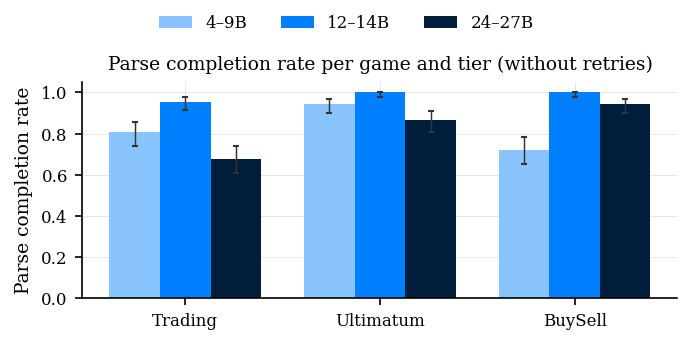

size       very_small  small  medium
game                                
BuySell         0.722  1.000   0.944
Trading         0.806  0.956   0.678
Ultimatum       0.944  1.000   0.867


In [4]:
#  Parse/protocol completion rate by game and tier (no_retries)
comp_src = MASTER[MASTER["condition"] == "no_retries"]
cc = (comp_src.groupby(["game", "size"])
      .agg(k=("completed", "sum"), n=("completed", "count")).reset_index())
cc["rate"] = cc["k"] / cc["n"]
cc[["lo", "hi"]] = cc.apply(lambda r: pd.Series(wilson_ci(r.k, r.n)), axis=1)

games = list(GAMES); x = np.arange(len(games)); width = 0.26
fig, ax = plt.subplots(figsize=(FULL_WIDTH * 0.75, 2.2))
for i, sz in enumerate(SIZES):
    sub = cc[cc["size"] == sz].set_index("game").reindex(games)
    pos = x + (i - 1) * width
    ax.bar(pos, sub["rate"], width, label=SIZE_LABELS[sz], color=tier_pal[sz])
    ax.errorbar(pos, sub["rate"],
                yerr=errbars_from_ci(sub["rate"].values, list(zip(sub["lo"], sub["hi"]))),
                fmt="none", ecolor="0.2", lw=0.7, capsize=1.5)
ax.set_xticks(x, games)
ax.set_ylabel("Parse completion rate"); ax.set_ylim(0, 1.05)
ax.set_title("Parse completion rate per game and tier (without retries)")
fig.legend(*ax.get_legend_handles_labels(), loc="outside upper center",
           ncols=3, frameon=False)
save_plot(fig, "parse_completion_no_retries")
plt.show()

print(cc.pivot_table(index="game", columns="size", values="rate")
      .reindex(columns=SIZES).round(3).to_string())

### Table 4.1 - completion by family and tier

Parse/protocol completion rate by game and parameter tier **without retries** (per family and pooled over families
with 95% Wilson CIs) and **with the retry-3** self-correction loop. A game counts toward a family
when one of its models occupies *either* seat, so each cross-play game is credited to both families;
the **All** columns pool over all 180 runs per (game, tier).

In [5]:
#  Table 4.1: parse/protocol completion rate by game x tier -- per family + pooled (Wilson 95% CI),
#  no_retries vs retry-3. A game counts toward a family when one of its models
#  occupies *either* seat, so cross-play games are credited to both families.
TIER_LABEL = style.SIZE_LABEL

def _fam_completion(df, fam):
    sub = df[(df["family_1"] == fam) | (df["family_2"] == fam)]
    return sub["completed"].mean() if len(sub) else np.nan

def _pooled_ci(df):
    k, n = int(df["completed"].sum()), len(df)
    if n == 0:
        return "-"
    lo, hi = wilson_ci(k, n)
    return f"{k / n:.2f} [{lo:.2f},{hi:.2f}]"

_t41 = []
for _game in GAMES:
    for _sz in SIZES:
        _nr = MASTER[(MASTER["condition"] == "no_retries")
                     & (MASTER["game"] == _game) & (MASTER["size"] == _sz)]
        _r3 = MASTER[(MASTER["condition"] == "retry3")
                     & (MASTER["game"] == _game) & (MASTER["size"] == _sz)]
        _t41.append({
            ("", "Game"): _game,
            ("", "Tier"): TIER_LABEL[_sz],
            ("No retries", "Gemma"):   f"{_fam_completion(_nr, 'Gemma'):.2f}",
            ("No retries", "Mistral"): f"{_fam_completion(_nr, 'Mistral'):.2f}",
            ("No retries", "Qwen"):    f"{_fam_completion(_nr, 'Qwen'):.2f}",
            ("No retries", "All"):     _pooled_ci(_nr),
            ("Retry-3", "All"):        _pooled_ci(_r3),
        })

TABLE_41 = pd.DataFrame(_t41)
TABLE_41.columns = pd.MultiIndex.from_tuples(TABLE_41.columns)
TABLE_41 = TABLE_41.set_index([("", "Game"), ("", "Tier")])
TABLE_41.index.names = ["Game", "Tier"]

try:
    display(TABLE_41)
except NameError:
    pass
print("Table 4.1 - Parse/protocol completion rate by game and parameter tier")
#print(TABLE_41.to_string())

No retries                                           Retry-3
                      Gemma Mistral  Qwen               All               All
Game      Tier                                                               
Trading   4–9B         0.82    0.79  0.80  0.81 [0.74,0.86]  0.91 [0.85,0.94]
          12–14B       0.97    0.96  0.93  0.96 [0.91,0.98]  1.00 [0.98,1.00]
          24–27B       0.70    0.74  0.59  0.68 [0.61,0.74]  0.99 [0.97,1.00]
Ultimatum 4–9B         0.97    0.95  0.92  0.94 [0.90,0.97]  0.99 [0.97,1.00]
          12–14B       1.00    1.00  1.00  1.00 [0.98,1.00]  1.00 [0.98,1.00]
          24–27B       0.89    0.82  0.88  0.87 [0.81,0.91]  1.00 [0.98,1.00]
BuySell   4–9B         0.58    0.79  0.79  0.72 [0.65,0.78]  0.95 [0.91,0.97]
          12–14B       1.00    1.00  1.00  1.00 [0.98,1.00]  1.00 [0.98,1.00]
          24–27B       0.96    0.92  0.96  0.94 [0.90,0.97]  1.00 [0.98,1.00]

Table 4.1 - Parse/protocol completion rate by game and parameter tier


### Why do they fail?

Each unrecoverable failure logs the parse error that ended the game. Here we look at the **no-retries (retry0)** condition: the raw failure modes a single malformed move produces before any self-correction (the retry3 survivors are covered in the two beats below). The by-condition table further down contrasts retry0 with retry3.

In [6]:
import re

def error_reason(msg):
    msg = msg or ""
    m = re.match(r"Missing required tag: <([^>]+)>", msg)
    if m:
        tag = m.group(1)
        return (f"missing tag <{tag}>" if tag in ("player answer", "my resources", "MOVE")
                else "missing tag (other)")
    if msg.startswith("Trade must have exactly two players"):
        return "malformed trade line (no '|')"
    if msg.startswith("Could not parse resource"):
        return "unparseable resource amount"
    return "other (lookup error)"

fail_rows = []
for _game, _gdir in GAMES.items():
    for _cond in CONDITIONS:
        for _root, _dirs, _files in os.walk(os.path.join(LOGS_ROOT, f"section_one/{_gdir}/{_cond}")):
            if "game_state.json" not in _files:
                continue
            with open(os.path.join(_root, "game_state.json")) as f:
                d = json.load(f)
            last = d["game_state"][-1]
            if last.get("current_iteration") == "END":
                continue
            ts = [s for s in d["game_state"] if s.get("current_iteration") not in ("START", "END")]
            who = clean_name(d["players"][(len(ts) - 1) % 2].get("model_id", "?"))
            fail_rows.append({"game": _game, "condition": _cond, "model": who,
                              "family": model_family(who),
                              "reason": error_reason(last.get("error_message"))})
FAILS = pd.DataFrame(fail_rows)
FAILS0 = FAILS[FAILS["condition"] == "no_retries"]  # raw failures, no safety net

counts = FAILS["reason"].value_counts()  # ordering used across the tables

def _with_total(df):
    out = df.copy(); out["total"] = out.sum(axis=1); return out

by_condition = _with_total(FAILS.groupby(["reason", "condition"]).size()
                           .unstack(fill_value=0).reindex(counts.index))
by_game = _with_total(FAILS0.groupby(["reason", "game"]).size()
                      .unstack(fill_value=0).reindex(counts.index).fillna(0)
                      .astype(int)[list(GAMES)])
by_model = FAILS0["model"].value_counts().rename("failures").to_frame()
by_model["family"] = by_model.index.map(model_family)

cap_style = [{"selector": "caption", "props": [("font-weight", "bold"),
              ("text-align", "left"), ("padding-bottom", "4px")]}]
for _df, _cap in [(by_condition, "Game-ending parse errors by reason and condition "
                                 "(retry0 vs retry3)"),
                  (by_game, "No-retry (retry0) failures by reason and game"),
                  (by_model, "No-retry (retry0) failures by model")]:
    display(_df.style.set_caption(_cap).set_table_styles(cap_style))

condition,no_retries,retry3,total
reason,,,
missing tag,58,0,58
unparseable resource amount,33,18,51
malformed trade line (no '|'),43,3,46
missing tag (other),19,5,24
missing tag,22,0,22
missing tag,18,0,18
other (lookup error),2,2,4


game,Trading,Ultimatum,BuySell,total
reason,,,,
missing tag,47,9,2,58
unparseable resource amount,26,3,4,33
malformed trade line (no '|'),3,0,40,43
missing tag (other),9,4,6,19
missing tag,16,0,6,22
missing tag,0,18,0,18
other (lookup error),0,0,2,2


,failures,family
model,,
gemma-3-4b-it,69,Gemma
Qwen3.5-27B,45,Qwen
Mistral-Small-3.2-24B-2506,43,Mistral
Qwen3.5-9B,24,Qwen
Ministral-3-14B-2512,5,Mistral
gemma-3-27b-it,4,Gemma
Qwen3-14B,3,Qwen
Ministral-3-8B-2512,2,Mistral


**What actually breaks**, by reason and game, **without retries (retry0)**: each bar is a game-ending parse error, colored by the game it occurred in. Trading drives the missing `<player answer>` and unparseable-resource errors, BuySell the malformed trade line, Ultimatum the missing `<MOVE>`.

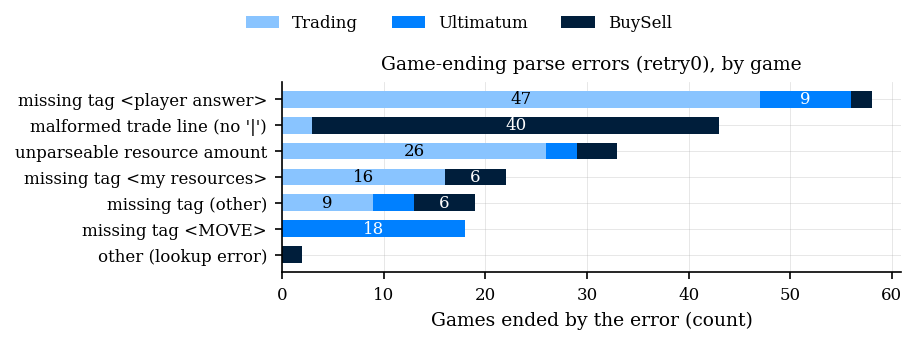

In [7]:
#  Which game each failure mode comes from
by_game = (FAILS0.groupby(["reason", "game"]).size().unstack(fill_value=0)
           .reindex(columns=list(GAMES)))
by_game = by_game.loc[by_game.sum(1).sort_values(ascending=False).index]

parse_error_pal = {"Trading": BAR3[0], "Ultimatum": BAR3[1], "BuySell": BAR3[2]}
txt = {"Trading": "black", "Ultimatum": "white", "BuySell": "white"}
fig, ax = plt.subplots(figsize=(FULL_WIDTH, 2.2))
left = np.zeros(len(by_game))
for g in GAMES:
    vals = by_game[g].values
    ax.barh(by_game.index, vals, left=left, color=parse_error_pal[g], label=g, height=0.65)
    for y, (v, l) in enumerate(zip(vals, left)):
        if v >= 6:
            ax.text(l + v / 2, y, str(v), ha="center", va="center",
                    fontsize=8, color=txt[g])
    left += vals
ax.invert_yaxis()
ax.set_xlabel("Games ended by the error (count)")
ax.set_title("Game-ending parse errors (retry0), by game")
fig.legend(*ax.get_legend_handles_labels(), loc="outside upper center",
           ncols=3, frameon=False)
save_plot(fig, "parse_errors_by_game")
plt.show()

### Which models cause them?

The same **no-retry (retry0)** failures attributed to the model that emitted the fatal move. Format fragility is far from uniform across the nine models.

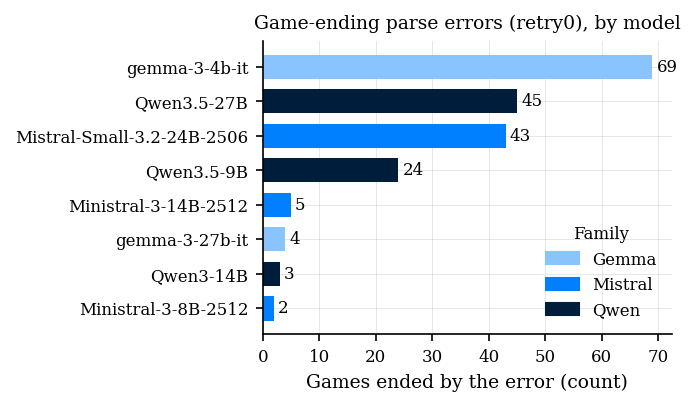

                     model  family  failures
             gemma-3-4b-it   Gemma        69
               Qwen3.5-27B    Qwen        45
Mistral-Small-3.2-24B-2506 Mistral        43
                Qwen3.5-9B    Qwen        24
      Ministral-3-14B-2512 Mistral         5
            gemma-3-27b-it   Gemma         4
                 Qwen3-14B    Qwen         3
       Ministral-3-8B-2512 Mistral         2


In [8]:
mc = (FAILS0.groupby(["model", "family"]).size()
      .reset_index(name="failures").sort_values("failures", ascending=False))
bar_colors = mc["family"].map(fam_pal).fillna(BAR3[0])
fig, ax = plt.subplots(figsize=(FULL_WIDTH * 0.75, 2.6))
bars = ax.barh(mc["model"], mc["failures"], color=bar_colors, height=0.7)
ax.bar_label(bars, fontsize=8, padding=2)
ax.invert_yaxis()
ax.set_xlabel("Games ended by the error (count)")
ax.set_title("Game-ending parse errors (retry0), by model")
handles = [plt.Rectangle((0, 0), 1, 1, color=fam_pal[f], label=f)
           for f in FAMILIES if f in set(mc["family"])]
ax.legend(handles=handles, title="Family", frameon=False,
          fontsize=8, title_fontsize=8, loc="lower right")
save_plot(fig, "parse_errors_by_model")
plt.show()

print(mc.to_string(index=False))

### Does a retry loop help?

The self-correction loop lets a model re-emit a move up to three times. Three retries pull almost every cell close to ≈1.0, with the main exceptions at the very-small tier (Trading 0.906, BuySell 0.950): the no-retry dips are mostly format failures, not models that cannot finish a negotiation.

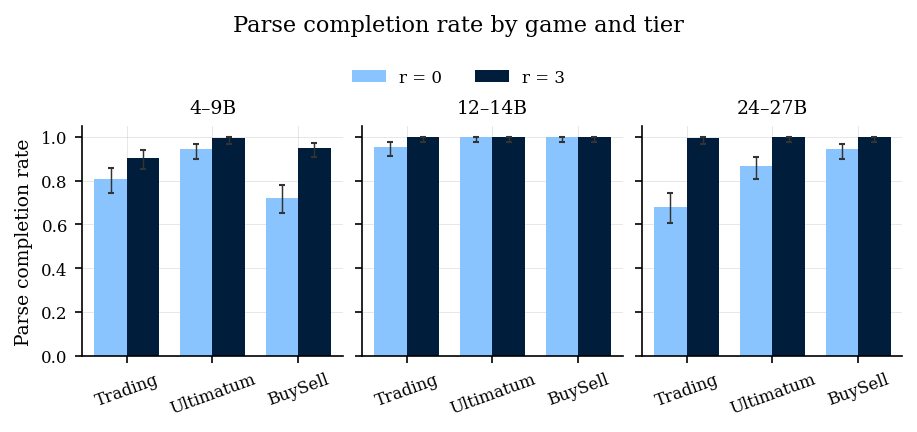

In [9]:
#  Completion: r=0 vs r=3, by game, faceted by tier
rec = (MASTER.groupby(["size", "condition", "game"])
       .agg(k=("completed", "sum"), n=("completed", "count")).reset_index())
rec["rate"] = rec["k"] / rec["n"]
rec[["lo", "hi"]] = rec.apply(lambda r: pd.Series(wilson_ci(r.k, r.n)), axis=1)

cond_pal = {"no_retries": BAR2[0], "retry3": BAR2[1]}
cond_lbl = {"no_retries": "r = 0", "retry3": "r = 3"}
games = list(GAMES); x = np.arange(len(games)); width = 0.38
fig, axes = plt.subplots(1, 3, figsize=(FULL_WIDTH, 2.2), sharey=True)
for ax, sz in zip(axes, SIZES):
    for j, cond in enumerate(["no_retries", "retry3"]):
        sub = rec[(rec["size"] == sz) & (rec["condition"] == cond)].set_index("game").reindex(games)
        pos = x + (j - 0.5) * width
        ax.bar(pos, sub["rate"], width, label=cond_lbl[cond], color=cond_pal[cond])
        ax.errorbar(pos, sub["rate"],
                    yerr=errbars_from_ci(sub["rate"].values, list(zip(sub["lo"], sub["hi"]))),
                    fmt="none", ecolor="0.2", lw=0.7, capsize=1.5)
    ax.set_xticks(x, games, rotation=20)
    ax.set_title(SIZE_LABELS[sz])
axes[0].set_ylabel("Parse completion rate"); axes[0].set_ylim(0, 1.05)
fig.suptitle("Parse completion rate by game and tier", y=1.24)
fig.legend(*axes[0].get_legend_handles_labels(), loc="upper center",
           bbox_to_anchor=(0.5, 1.12), ncols=2, frameon=False)
save_plot(fig, "parse_completion_retry_bars")
plt.show()

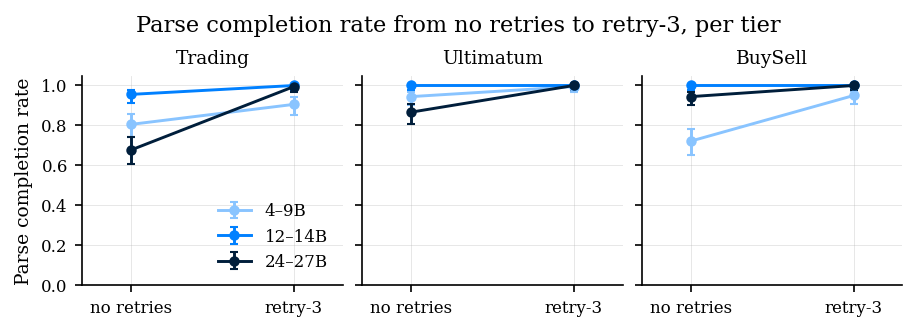

In [10]:
#  Completion: no-retries -> retry-3 slope, per tier, faceted by game
order = ["no_retries", "retry3"]; xt = [0, 1]
fig, axes = plt.subplots(1, 3, figsize=(FULL_WIDTH, 2.1), sharey=True)
for ax, game in zip(axes, GAMES):
    for sz in SIZES:
        sub = (rec[(rec["game"] == game) & (rec["size"] == sz)]
               .set_index("condition").reindex(order))
        ax.errorbar(xt, sub["rate"],
                    yerr=errbars_from_ci(sub["rate"].values, list(zip(sub["lo"], sub["hi"]))),
                    marker="o", ms=4, lw=1.4, capsize=2,
                    color=tier_pal[sz], label=SIZE_LABELS[sz])
    ax.set_xticks(xt, ["no retries", "retry-3"])
    ax.set_xlim(-0.3, 1.3); ax.set_title(game)
axes[0].set_ylabel("Parse completion rate"); axes[0].set_ylim(0, 1.05)
axes[0].legend(loc="lower right", frameon=False)
fig.suptitle("Parse completion rate from no retries to retry-3, per tier")
save_plot(fig, "parse_completion_retry_slope")
plt.show()

### How much correction does it take?

Among the moves that actually triggered the loop: how often a retry is needed, where the move finally parses, and the share of triggered moves the budget resolves.

Parse completion rate (game level, pooled over models):
size                  very_small  small  medium
condition  game                                
no_retries BuySell         0.722  1.000   0.944
           Trading         0.806  0.956   0.678
           Ultimatum       0.944  1.000   0.867
retry3     BuySell         0.950  1.000   1.000
           Trading         0.906  1.000   0.994
           Ultimatum       0.994  1.000   1.000


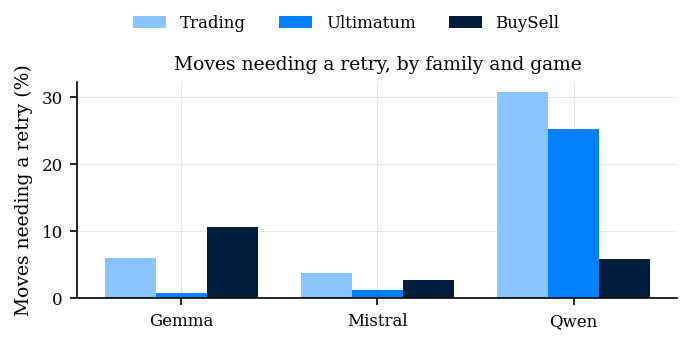


Retried moves by family x game (counts):
game     BuySell  Trading  Ultimatum
family                              
Gemma         57       31          3
Mistral       14       20          5
Qwen          30      158         96


In [11]:
_mvall = model_view(MASTER)
comp = (_mvall.groupby(["condition", "game", "size"])["completed"].mean()
        .unstack("size").reindex(columns=SIZES).round(3))
print("Parse completion rate (game level, pooled over models):")
print(comp.to_string())

turn_rows = []
for _, r in RETRY3.iterrows():
    rpt = r["retries_per_turn"]
    for t, k in enumerate(rpt):
        who = r["model_1"] if t % 2 == 0 else r["model_2"]
        failed = (not r["completed"]) and (t == len(rpt) - 1)
        turn_rows.append({"game": r["game"], "size": r["size"], "model": who,
                          "family": model_family(who), "turn": t + 1,
                          "retries": 3 if failed else k, "failed": failed})
TURNS = pd.DataFrame(turn_rows)

# % of moves needing at least one retry, by family and game
rate = (TURNS.assign(retried=TURNS["retries"] > 0)
        .groupby(["family", "game"])["retried"].mean().mul(100).reset_index())
x = np.arange(len(FAMILIES)); width = 0.26
fig, ax = plt.subplots(figsize=(FULL_WIDTH * 0.75, 2.2))
for gi, game in enumerate(GAMES):
    sub = rate[rate["game"] == game].set_index("family").reindex(FAMILIES)
    ax.bar(x + (gi - 1) * width, sub["retried"], width, label=game, color=game_pal[game])
ax.set_xticks(x, FAMILIES)
ax.set_ylabel("Moves needing a retry (%)")
ax.set_title("Moves needing a retry, by family and game")
fig.legend(*ax.get_legend_handles_labels(), loc="outside upper center",
           ncols=3, frameon=False)
save_plot(fig, "moves_needing_retry_by_family_game")
plt.show()

print("\nRetried moves by family x game (counts):")
print(TURNS[TURNS["retries"] > 0].groupby(["family", "game"]).size()
      .unstack(fill_value=0).to_string())

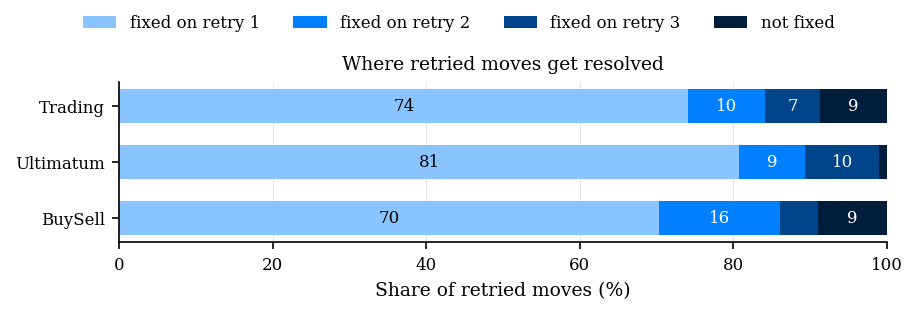

414 of 4265 moves (9.7%) needed a retry; 75% of those were fixed by the first retry; 28 exhausted the budget and lost the game (= the 28 incomplete retry3 games, almost all format/parse errors).

28 distinct unrecovered retry3 games. Of those, the number that involve each family on EITHER seat
(a game has two families, so these overlap and sum to 2 x 28 = 56):
Gemma      28
Mistral    19
Qwen        9

-> all 28 games involve a Gemma model; the other seat is Mistral or Qwen, hence 19 + 9 = 28.

Which models, grouped by family (count = games that model appears in):
  Gemma: gemma-3-4b-it (27), gemma-3-27b-it (1)
  Mistral: Ministral-3-8B-2512 (19)
  Qwen: Qwen3.5-9B (8), Qwen3.5-27B (1)

Model that emitted the final budget-exhausting move (28 games -- the causal failer):
model
gemma-3-4b-it          26
Qwen3.5-27B             1
Ministral-3-8B-2512     1


In [12]:
#  Among retried moves, where did they get fixed? (retry3)
retried = TURNS[(TURNS["retries"] > 0) | TURNS["failed"]].copy()
retried["outcome"] = np.where(retried["failed"], "not fixed",
                              retried["retries"].map(lambda k: f"fixed on retry {k}"))
order = ["fixed on retry 1", "fixed on retry 2", "fixed on retry 3", "not fixed"]
shares = (retried.groupby("game")["outcome"].value_counts(normalize=True)
          .unstack().reindex(columns=order).fillna(0).reindex(list(GAMES)) * 100)

colors = BAR4
dark_text = {"fixed on retry 2", "fixed on retry 3", "not fixed"}
fig, ax = plt.subplots(figsize=(FULL_WIDTH, 2.0))
left = np.zeros(len(shares))
for col, color in zip(order, colors):
    vals = shares[col].values
    ax.barh(shares.index, vals, left=left, color=color, label=col, height=0.6)
    for y, (v, l) in enumerate(zip(vals, left)):
        if v > 7:
            ax.text(l + v / 2, y, f"{v:.0f}", ha="center", va="center", fontsize=8,
                    color="white" if col in dark_text else "black")
    left += vals
ax.set_xlim(0, 100); ax.set_xlabel("Share of retried moves (%)")
ax.invert_yaxis()
ax.set_title("Where retried moves get resolved")
fig.legend(*ax.get_legend_handles_labels(), loc="outside upper center",
           ncols=4, frameon=False)
save_plot(fig, "retried_moves_resolution")
plt.show()

n_retried, n_turns = len(retried), len(TURNS)
print(f"{n_retried} of {n_turns} moves ({n_retried / n_turns:.1%}) needed a retry; "
      f"{(retried['outcome'] == 'fixed on retry 1').mean():.0%} of those were fixed by the "
      f"first retry; {int(retried['failed'].sum())} exhausted the budget and lost the game "
      f"(= the {int((~RETRY3['completed']).sum())} incomplete retry3 games, almost all format/parse errors).")
#  Who is in the unrecovered retry3 games? (ch.4 "mostly those involving Gemma models")
#  Each game has two seats; a cross-play game is credited to *both* players' families,
#  so the family counts below OVERLAP and sum to 2 x (number of games), not to the
#  number of games. The headline number of distinct games is len(_inc).
_inc = RETRY3[~RETRY3["completed"]]
_fam_inc = (pd.concat([_inc["family_1"], _inc["family_2"]])
            .value_counts().reindex(FAMILIES).fillna(0).astype(int))
_mod_inc = pd.concat([_inc["model_1"], _inc["model_2"]]).value_counts()
print(f"\n{len(_inc)} distinct unrecovered retry3 games. "
      f"Of those, the number that involve each family on EITHER seat")
print(f"(a game has two families, so these overlap and sum to 2 x {len(_inc)} = {2 * len(_inc)}):")
print(_fam_inc.to_string())
print(f"\n-> all {len(_inc)} games involve a Gemma model; the other seat is "
      f"Mistral or Qwen, hence {_fam_inc.get('Mistral', 0)} + {_fam_inc.get('Qwen', 0)} "
      f"= {_fam_inc.get('Mistral', 0) + _fam_inc.get('Qwen', 0)}.")
print("\nWhich models, grouped by family (count = games that model appears in):")
for _fam in FAMILIES:
    _sub = _mod_inc[[m for m in _mod_inc.index if model_family(m) == _fam]]
    if len(_sub):
        print(f"  {_fam}: " + ", ".join(f"{m} ({int(c)})" for m, c in _sub.items()))

#  Causal view: which model actually EMITTED the budget-exhausting move (TURNS flags it
#  as `failed`). This is the model responsible for the loss, not just present in the game.
_failed = TURNS[TURNS["failed"]]
print(f"\nModel that emitted the final budget-exhausting move ({len(_failed)} games -- the causal failer):")
print(_failed["model"].value_counts().to_string())


In [13]:
#  Table: what self-correction resolves (move level, retry3) 
sc = TURNS[(TURNS["retries"] > 0) | TURNS["failed"]].copy()
sc["solved"] = ~sc["failed"]
sc["solved_1st"] = sc["solved"] & (sc["retries"] == 1)

def sc_table(by):
    g = sc.groupby(by)
    t = pd.DataFrame({
        "total_moves": TURNS.groupby(by).size(),
        "needing_sc": g.size(),
        "solved": g["solved"].sum().astype(int),
        "still_failed": g["failed"].sum().astype(int),
        "solve_rate_%": g["solved"].mean().mul(100),
        "solved_on_1st_%": g["solved_1st"].mean().mul(100),
    })
    t.insert(2, "needing_sc_%", t["needing_sc"] / t["total_moves"] * 100)
    return t

def overall():
    t = pd.DataFrame({
        "total_moves": [len(TURNS)], "needing_sc": [len(sc)],
        "needing_sc_%": [len(sc) / len(TURNS) * 100],
        "solved": [int(sc["solved"].sum())], "still_failed": [int(sc["failed"].sum())],
        "solve_rate_%": [sc["solved"].mean() * 100],
        "solved_on_1st_%": [sc["solved_1st"].mean() * 100],
    }, index=["All"])
    return t[["total_moves", "needing_sc", "needing_sc_%", "solved", "still_failed",
              "solve_rate_%", "solved_on_1st_%"]]

by_game = pd.concat([sc_table("game").reindex(list(GAMES)), overall()])
by_tier = sc_table("size").reindex(SIZES).rename(index=SIZE_LABELS)

print("Self-correction resolution by game (retry3, move level):")
display(by_game.round(1))
print("\nBy tier:")
display(by_tier.round(1))

Self-correction resolution by game (retry3, move level):


,total_moves,needing_sc,needing_sc_%,solved,still_failed,solve_rate_%,solved_on_1st_%
Trading,1552,209,13.5,191,18,91.4,74.2
Ultimatum,1152,104,9.0,103,1,99.0,80.8
BuySell,1561,101,6.5,92,9,91.1,70.3
All,4265,414,9.7,386,28,93.2,74.9



By tier:


,total_moves,needing_sc,needing_sc_%,solved,still_failed,solve_rate_%,solved_on_1st_%
size,,,,,,,
4–9B,1313,150,11.4,123,27,82.0,65.3
12–14B,1388,202,14.6,202,0,100.0,77.2
24–27B,1564,62,4.0,61,1,98.4,90.3


### Does the retry loop changes who wins?

We now investigate whether the retry loop changes the *outcomes*.

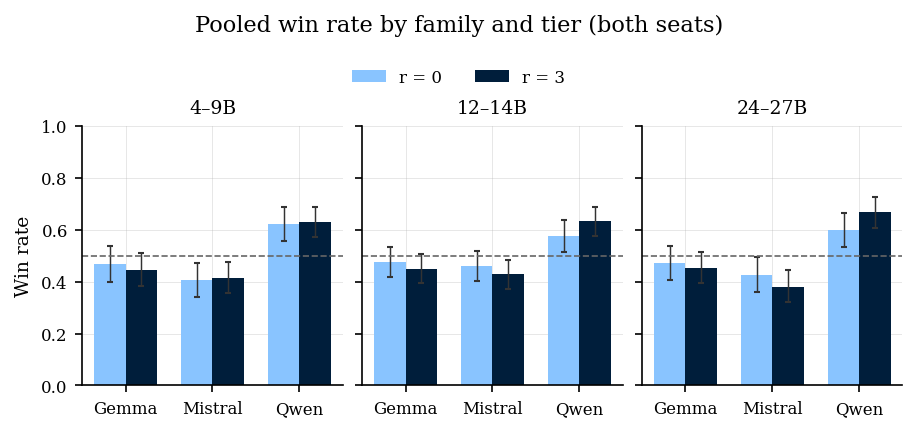

condition           no_retries  retry3
size       family                     
very_small Gemma         0.466   0.445
           Mistral       0.405   0.414
           Qwen          0.624   0.630
small      Gemma         0.475   0.450
           Mistral       0.459   0.428
           Qwen          0.576   0.634
medium     Gemma         0.471   0.453
           Mistral       0.427   0.380
           Qwen          0.601   0.668

Spearman rho between the two condition rankings (9 family x tier cells): 0.917


In [14]:
#  A1: pooled win rate by family and tier, retry3 vs no_retries
MV_NR = model_view(MASTER[MASTER["condition"] == "no_retries"].copy())
rows = []
for cond, mv in [("no_retries", MV_NR), ("retry3", MV)]:
    d_ = mv[mv["win"].notna()]
    a = d_.groupby(["size", "family"]).agg(wins=("win", "sum"), n=("win", "count")).reset_index()
    a["win_rate"] = a["wins"] / a["n"]
    a[["lo", "hi"]] = a.apply(lambda r: pd.Series(wilson_ci(r.wins, r.n)), axis=1)
    rows.append(a.assign(condition=cond))
ab = pd.concat(rows, ignore_index=True)

fig, axes = plt.subplots(1, 3, figsize=(FULL_WIDTH, 2.2), sharey=True)
for ax, size in zip(axes, SIZES):
    sub = ab[ab["size"] == size]
    x = np.arange(len(FAMILIES))
    for j, cond in enumerate(["no_retries", "retry3"]):
        s = sub[sub["condition"] == cond].set_index("family").reindex(FAMILIES)
        pos = x + (j - 0.5) * 0.36
        ax.bar(pos, s["win_rate"], 0.36, color=cond_pal[cond])
        ax.errorbar(pos, s["win_rate"],
                    yerr=errbars_from_ci(s["win_rate"].values, list(zip(s["lo"], s["hi"]))),
                    fmt="none", ecolor="0.2", lw=0.7, capsize=1.5)
    ax.axhline(0.5, ls="--", lw=0.8, color="0.4")
    ax.set_xticks(x, FAMILIES)
    ax.set_title(SIZE_LABELS[size])
axes[0].set_ylabel("Win rate"); axes[0].set_ylim(0, 1)
fig.suptitle("Pooled win rate by family and tier (both seats)", y=1.24)
_h = [mpatches.Patch(facecolor=cond_pal["no_retries"], label="r = 0"),
      mpatches.Patch(facecolor=cond_pal["retry3"], label="r = 3")]
fig.legend(handles=_h, loc="upper center", bbox_to_anchor=(0.5, 1.12), ncols=2, frameon=False)
save_plot(fig, "winrate_retry_ablation")
plt.show()

pvt = (ab.pivot_table(index=["size", "family"], columns="condition", values="win_rate")
       .reindex(SIZES, level=0))
rho_c, _ = sps.spearmanr(pvt["retry3"], pvt["no_retries"])
print(pvt.round(3).to_string())
print(f"\nSpearman rho between the two condition rankings (9 family x tier cells): {rho_c:.3f}")

The retry mechanism doesn't change who wins. Qwen leads and Mistral trails in every tier (Spearman ρ = 0.917 across the 9 family × tier win rates).

<!-- INSIGHTS_COMPLETION -->
**Insights**

- **How often ->** Completion does not increase monotonically with model size; Small models have a higher completion rate(0.96-1.00) than medium(0.68-0.94); 

- **Why -> each game has a signature failure mode** Trading dies to missing
  `<player answer>` tags (47) and unparseable resource amounts (26); BuySell to malformed trade
  lines missing the `|` separator (40); Ultimatum to a missing `<MOVE>` tag (18).

- **Who ->** Of 195 no-retry (retry0) failures, `gemma-3-4b-it` alone causes 69; the medium dip is driven by Qwen3.5-27B (45) and Mistral-Small
  (43), while `gemma-3-12b-it` never fails and `gemma-3-27b-it` only 4 times. 

- **Does it help -> three retries recover almost everything.** `retry3` completion is ≥ 0.99 everywhere except very_small (Trading 0.906, BuySell 0.950).

- **How much ->** 9.7% of all moves are malformed, **75% of those are fixed by the first retry**, and only 28 / 1620 games still die. Qwen is the heaviest retry consumer (284 of 414 retried moves, in Trading and  Ultimatum) yet the strongest negotiator (§2) and almost never fatal (1 of 28); Gemma retries less but fails hardest: **26 of the 28 budget-exhausting failures are `gemma-3-4b-it`**.


## 2. Who negotiates best? (retry3)

The remaining sections use the `retry3` condition; §1 showed it largely removes the parse-completion problem. Win rate is over payoff-valid completed games with a winner (ties are excluded); the dashed line marks parity (0.5) and error bars are 95% Wilson CIs. 

### Who wins?


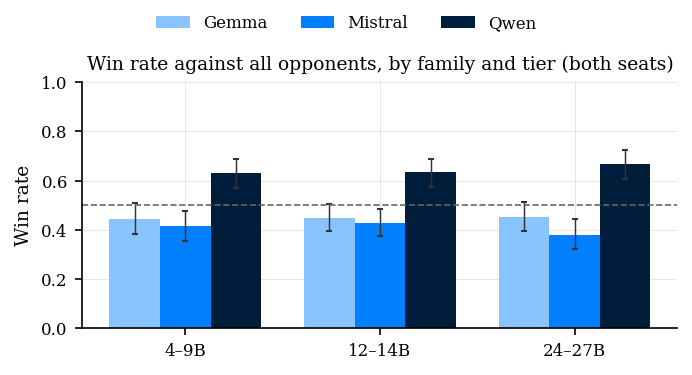

      size  family  wins   n  win_rate    lo    hi
    medium   Gemma 121.0 267     0.453 0.395 0.513
    medium Mistral  89.0 234     0.380 0.321 0.444
    medium    Qwen 161.0 241     0.668 0.606 0.724
     small   Gemma 135.0 300     0.450 0.395 0.507
     small Mistral 128.0 299     0.428 0.373 0.485
     small    Qwen 173.0 273     0.634 0.575 0.689
very_small   Gemma 106.0 238     0.445 0.384 0.509
very_small Mistral 104.0 251     0.414 0.355 0.476
very_small    Qwen 167.0 265     0.630 0.571 0.686


In [15]:
#  P1: pooled win rate vs all opponents, by family and tier
dec = MV[MV["win"].notna()]
agg = (dec.groupby(["size", "family"])
       .agg(wins=("win", "sum"), n=("win", "count")).reset_index())
agg["win_rate"] = agg["wins"] / agg["n"]
agg[["lo", "hi"]] = agg.apply(lambda r: pd.Series(wilson_ci(r.wins, r.n)), axis=1)

fig, ax = plt.subplots(figsize=(FULL_WIDTH * 0.75, 2.4))
x = np.arange(len(SIZES)); width = 0.26
for i, fam in enumerate(FAMILIES):
    sub = agg[agg["family"] == fam].set_index("size").reindex(SIZES)
    pos = x + (i - 1) * width
    ax.bar(pos, sub["win_rate"], width, label=fam, color=fam_pal[fam])
    ax.errorbar(pos, sub["win_rate"],
                yerr=errbars_from_ci(sub["win_rate"].values, list(zip(sub["lo"], sub["hi"]))),
                fmt="none", ecolor="0.2", lw=0.7, capsize=1.5)
ax.axhline(0.5, ls="--", lw=0.8, color="0.4")
ax.set_xticks(x, [SIZE_LABELS[s] for s in SIZES])
ax.set_ylabel("Win rate"); ax.set_ylim(0, 1)
ax.set_title("Win rate against all opponents, by family and tier (both seats)")
fig.legend(*ax.get_legend_handles_labels(), loc="outside upper center",
           ncols=3, frameon=False)
save_plot(fig, "winrate_family_tier")
plt.show()

print(agg.assign(win_rate=agg.win_rate.round(3), lo=agg.lo.round(3), hi=agg.hi.round(3))
      .to_string(index=False))

Across parameter tiers the model rankings remain: Qwen -> Gemma -> Mistral.

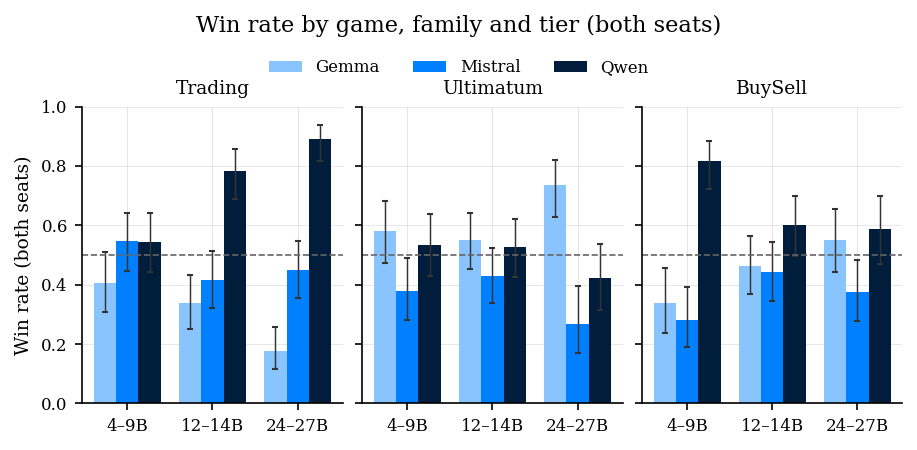

size               very_small  small  medium
game      family                            
BuySell   Gemma         0.338  0.464   0.550
          Mistral       0.280  0.442   0.375
          Qwen          0.816  0.602   0.588
Trading   Gemma         0.404  0.337   0.176
          Mistral       0.546  0.414   0.449
          Qwen          0.543  0.784   0.892
Ultimatum Gemma         0.580  0.549   0.734
          Mistral       0.380  0.429   0.268
          Qwen          0.535  0.526   0.423


In [16]:
#  P2: win rate per game, family and tier
aggg = (dec.groupby(["game", "size", "family"])
        .agg(wins=("win", "sum"), n=("win", "count")).reset_index())
aggg["win_rate"] = aggg["wins"] / aggg["n"]
aggg[["lo", "hi"]] = aggg.apply(lambda r: pd.Series(wilson_ci(r.wins, r.n)), axis=1)

fig, axes = plt.subplots(1, 3, figsize=(FULL_WIDTH, 2.45), sharey=True)
for ax, game in zip(axes, GAMES):
    gsub = aggg[aggg["game"] == game]
    for i, fam in enumerate(FAMILIES):
        sub = gsub[gsub["family"] == fam].set_index("size").reindex(SIZES)
        pos = np.arange(len(SIZES)) + (i - 1) * 0.26
        ax.bar(pos, sub["win_rate"], 0.26, label=fam, color=fam_pal[fam])
        ax.errorbar(pos, sub["win_rate"],
                    yerr=errbars_from_ci(sub["win_rate"].values, list(zip(sub["lo"], sub["hi"]))),
                    fmt="none", ecolor="0.2", lw=0.7, capsize=1.5)
    ax.axhline(0.5, ls="--", lw=0.8, color="0.4")
    ax.set_xticks(np.arange(len(SIZES)), [SIZE_LABELS[s] for s in SIZES])
    ax.set_title(game)
axes[0].set_ylabel("Win rate (both seats)"); axes[0].set_ylim(0, 1)
fig.suptitle("Win rate by game, family and tier (both seats)", y=1.16)
fig.legend(*axes[0].get_legend_handles_labels(), loc="upper center",
           bbox_to_anchor=(0.5, 1.08), ncols=3, frameon=False)
save_plot(fig, "winrate_game_family_tier")
plt.show()

print(aggg.pivot_table(index=["game", "family"], columns="size", values="win_rate")
      .reindex(columns=SIZES).round(3).to_string())

Looking into win rate by game, we notice that actually Gemma outperforms Qwen in the Ultimatum Game.

### Are WinRate and Payoff Correlated?

Win rate ignores *margins*. 

Payoffs are not comparable across games in native units (Trading resource delta, Ultimatum dollars, BuySell profit), so for pooled views each game's payoff is min-max scaled to its feasible range (`PAYOFF_BOUNDS`: Trading ±30 units, Ultimatum 0–100 dollars, BuySell −40–60 surplus, since the price is bounded by the buyer's 100 ZUP); 


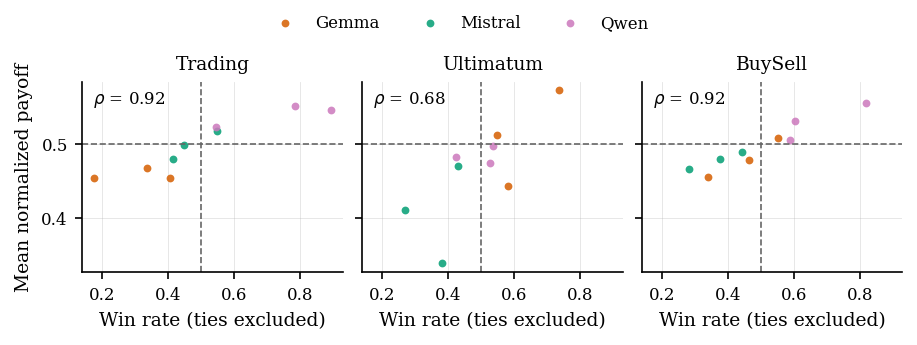

Overall Spearman rho = 0.807 (p = 3.7e-07, n = 27 family x game x tier cells)
  Trading: rho = 0.92 (n = 9)
  Ultimatum: rho = 0.68 (n = 9)
  BuySell: rho = 0.92 (n = 9)


In [17]:
#  P3: win rate vs normalized payoff, by game (one point per family x tier)
pv = MV[MV["completed"] & MV["payoff_valid"]].copy()
_plo = pv["game"].map(lambda g: PAYOFF_BOUNDS[g][0])
_phi = pv["game"].map(lambda g: PAYOFF_BOUNDS[g][1])
pv["payoff_norm"] = (pv["payoff"] - _plo) / (_phi - _plo)

wp = (dec.groupby(["game", "size", "family"])["win"].mean().rename("win_rate").reset_index()
      .merge(pv.groupby(["game", "size", "family"])["payoff_norm"].mean().reset_index()))
rho, pval = sps.spearmanr(wp["win_rate"], wp["payoff_norm"])

fig, axes = plt.subplots(1, 3, figsize=(FULL_WIDTH, 2.2), sharex=True, sharey=True)
for ax, game in zip(axes, GAMES):
    gsub = wp[wp["game"] == game]
    for fam in FAMILIES:
        sub = gsub[gsub["family"] == fam]
        ax.scatter(sub["win_rate"], sub["payoff_norm"], s=14, color=dot_pal[fam],
                   alpha=0.85, lw=0, label=fam)
    ax.axhline(0.5, ls="--", lw=0.8, color="0.4")
    ax.axvline(0.5, ls="--", lw=0.8, color="0.4")
    r_g, _ = sps.spearmanr(gsub["win_rate"], gsub["payoff_norm"])
    ax.text(0.04, 0.96, f"$\\rho$ = {r_g:.2f}", transform=ax.transAxes, va="top", fontsize=8)
    ax.set_title(game)
    ax.set_xlabel("Win rate (ties excluded)")
axes[0].set_ylabel("Mean normalized payoff")
fig.legend(*axes[0].get_legend_handles_labels(), loc="outside upper center",
           ncols=3, frameon=False)
save_plot(fig, "winrate_vs_normalized_payoff")
plt.show()

print(f"Overall Spearman rho = {rho:.3f} (p = {pval:.1e}, n = {len(wp)} family x game x tier cells)")
for game in GAMES:
    gsub = wp[wp["game"] == game]
    r_g, p_g = sps.spearmanr(gsub["win_rate"], gsub["payoff_norm"])
    print(f"  {game}: rho = {r_g:.2f} (n = {len(gsub)})")

**Payoff mostly agrees with WinRate (Ultimatum is an exception).** 

In Ultimatum this correlation is smaller because some family/tier cells can win decisive games while still earning modest average payoff. If both models cannot agree on a split, the payoff is 0. Gemma 4B rejects a high percentage of splits (see the plot below), so its payoff is lower than its win rate alone would suggest.

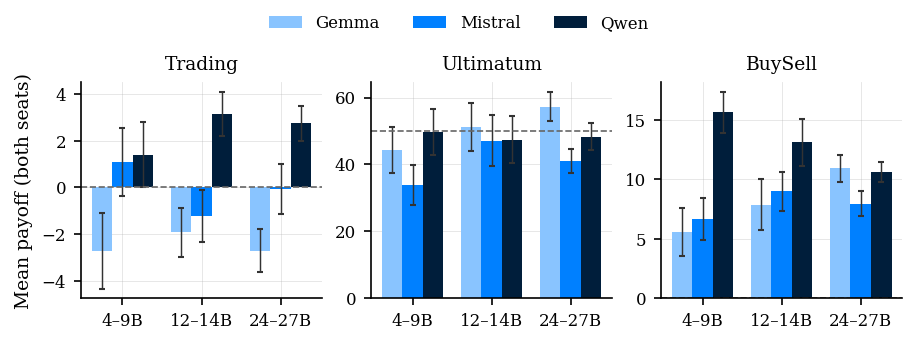

size               very_small  small  medium
game      family                            
BuySell   Gemma          5.57   7.87   10.92
          Mistral        6.70   9.02    7.98
          Qwen          15.64  13.12   10.60
Trading   Gemma         -2.72  -1.92   -2.71
          Mistral        1.10  -1.23   -0.05
          Qwen           1.40   3.15    2.76
Ultimatum Gemma         44.40  51.31   57.31
          Mistral       33.85  47.07   41.05
          Qwen          49.72  47.44   48.31


In [18]:
#  P4: mean payoff per game (native units), by family and tier
def _sem(s):
    s = s.dropna()
    return s.std(ddof=1) / np.sqrt(len(s)) if len(s) > 1 else 0.0

gp = (pv.groupby(["game", "size", "family"])
      .agg(mean=("payoff", "mean"), sem=("payoff", _sem)).reset_index())
gp["lo"] = gp["mean"] - 1.96 * gp["sem"]
gp["hi"] = gp["mean"] + 1.96 * gp["sem"]

NEUTRAL = {"Trading": 0, "Ultimatum": 50, "BuySell": 0}
fig, axes = plt.subplots(1, 3, figsize=(FULL_WIDTH, 2.2))
for ax, game in zip(axes, GAMES):
    gsub = gp[gp["game"] == game]
    for i, fam in enumerate(FAMILIES):
        sub = gsub[gsub["family"] == fam].set_index("size").reindex(SIZES)
        pos = np.arange(len(SIZES)) + (i - 1) * 0.26
        ax.bar(pos, sub["mean"], 0.26, label=fam, color=fam_pal[fam])
        ax.errorbar(pos, sub["mean"],
                    yerr=errbars_from_ci(sub["mean"].values, list(zip(sub["lo"], sub["hi"]))),
                    fmt="none", ecolor="0.2", lw=0.7, capsize=1.5)
    ax.axhline(NEUTRAL[game], ls="--", lw=0.8, color="0.4")
    ax.set_xticks(np.arange(len(SIZES)), [SIZE_LABELS[s] for s in SIZES])
    ax.set_title(game)
axes[0].set_ylabel("Mean payoff (both seats)")
fig.legend(*axes[0].get_legend_handles_labels(), loc="outside upper center",
           ncols=3, frameon=False)
save_plot(fig, "mean_payoff_family_tier") 
plt.show()

print(gp.pivot_table(index=["game", "family"], columns="size", values="mean")
      .reindex(columns=SIZES).round(2).to_string())

In [19]:
#  T1: master summary table (retry3)
cm = MV[MV["outcome_valid"]]
summary = (cm.groupby(["size", "family", "model"])
           .agg(games=("win", "size"),
                win_rate=("win", "mean"),                 # mean ignores NaN ties
                decided=("win", "count"),
                tie_share=("win", lambda s: s.isna().mean()),
                deal_rate=("deal", "mean"),
                turns=("num_turns", "mean")).reset_index())
claim = (pv[pv["deal"]].groupby(["size", "family", "model"])["payoff_norm"]
         .mean().rename("claim_given_deal").reset_index())
pay = (cm[cm["payoff_valid"]].pivot_table(index=["size", "family", "model"],
       columns="game", values="payoff", aggfunc="mean")
       .rename(columns=lambda c: f"payoff_{c}"))
summary = (summary.merge(claim, on=["size", "family", "model"])
           .merge(pay, on=["size", "family", "model"]))
summary["size"] = pd.Categorical(summary["size"], SIZES, ordered=True)
summary = summary.sort_values(["size", "family"]).round(3)
display(summary.set_index(["size", "family", "model"]))


games  win_rate  decided  \
size       family  model                                                  
very_small Gemma   gemma-3-4b-it                 332     0.445      238   
           Mistral Ministral-3-8B-2512           340     0.414      251   
           Qwen    Qwen3.5-9B                    352     0.630      265   
small      Gemma   gemma-3-12b-it                359     0.450      300   
           Mistral Ministral-3-14B-2512          359     0.428      299   
           Qwen    Qwen3-14B                     360     0.634      273   
medium     Gemma   gemma-3-27b-it                359     0.453      267   
           Mistral Mistral-Small-3.2-24B-2506    360     0.380      234   
           Qwen    Qwen3.5-27B                   359     0.668      241   

                                               tie_share  deal_rate  turns  \
size       family  model                                                     
very_small Gemma   gemma-3-4b-it                   0.283      0.907  2.274   
           Mistral Ministral-3-8B-2512             0.262      0.921  2.685   
           Qwen    Qwen3.5-9B                      0.247      0.955  2.534   
small      Gemma   gemma-3-12b-it                  0.164      0.986  2.607   
           Mistral Ministral-3-14B-2512            0.167      1.000  2.630   
           Qwen    Qwen3-14B                       0.242      0.986  2.478   
medium     Gemma   gemma-3-27b-it                  0.256      0.981  3.072   
           Mistral Mistral-Small-3.2-24B-2506      0.350      0.981  2.847   
           Qwen    Qwen3.5-27B                     0.329      1.000  2.758   

                                               claim_given_deal  \
size       family  model                                          
very_small Gemma   gemma-3-4b-it                          0.485   
           Mistral Ministral-3-8B-2512                    0.464   
           Qwen    Qwen3.5-9B                             0.547   
small      Gemma   gemma-3-12b-it                         0.493   
           Mistral Ministral-3-14B-2512                   0.480   
           Qwen    Qwen3-14B                              0.527   
medium     Gemma   gemma-3-27b-it                         0.519   
           Mistral Mistral-Small-3.2-24B-2506             0.469   
           Qwen    Qwen3.5-27B                            0.512   

                                               payoff_BuySell  payoff_Trading  \
size       family  model                                                        
very_small Gemma   gemma-3-4b-it                        5.568          -2.718   
           Mistral Ministral-3-8B-2512                  6.699           1.101   
           Qwen    Qwen3.5-9B                          15.636           1.404   
small      Gemma   gemma-3-12b-it                       7.867          -1.925   
           Mistral Ministral-3-14B-2512                 9.017          -1.225   
           Qwen    Qwen3-14B                           13.117           3.150   
medium     Gemma   gemma-3-27b-it                      10.925          -2.706   
           Mistral Mistral-Small-3.2-24B-2506           7.975          -0.050   
           Qwen    Qwen3.5-27B                         10.600           2.756   

                                               payoff_Ultimatum  
size       family  model                                         
very_small Gemma   gemma-3-4b-it                         44.398  
           Mistral Ministral-3-8B-2512                   33.847  
           Qwen    Qwen3.5-9B                            49.725  
small      Gemma   gemma-3-12b-it                        51.311  
           Mistral Ministral-3-14B-2512                  47.067  
           Qwen    Qwen3-14B                             47.442  
medium     Gemma   gemma-3-27b-it                        57.308  
           Mistral Mistral-Small-3.2-24B-2506            41.050  
           Qwen    Qwen3.5-27B                           48.308

### Table 4.2 - cross-play per family and tier

Win rate over payoff-valid completed games and opponents (ties excluded, 95% Wilson CI) and mean payoff per game
(95% percentile-bootstrap CI). 

In [20]:
def _boot_mean_ci(x, n_boot=10000, seed=0):
    """(mean, lo, hi) via style.bootstrap_ci (deterministic, seed=0)."""
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return np.nan, np.nan, np.nan
    lo, hi = style.bootstrap_ci(x, n_boot=n_boot, seed=seed)
    return x.mean(), lo, hi

_dec = MV[MV["win"].notna()]
_pv = MV[MV["completed"] & MV["payoff_valid"]]

_t42 = []
for _sz in SIZES:
    for _fam in FAMILIES:
        _d = _dec[(_dec["size"] == _sz) & (_dec["family"] == _fam)]
        _w, _n = int(_d["win"].sum()), len(_d)
        _wlo, _whi = wilson_ci(_w, _n)
        _row = {
            "Tier": TIER_LABEL[_sz],
            "Family": _fam,
            "Win rate": f"{_w / _n:.2f} [{_wlo:.2f},{_whi:.2f}]" if _n else "-",
        }
        for _game in GAMES:
            _p = _pv[(_pv["size"] == _sz) & (_pv["family"] == _fam)
                     & (_pv["game"] == _game)]["payoff"].values
            _m, _lo, _hi = _boot_mean_ci(_p)
            _row[_game] = f"{_m:.1f} [{_lo:.1f},{_hi:.1f}]"
        _t42.append(_row)

TABLE_42 = pd.DataFrame(_t42).set_index(["Tier", "Family"])

try:
    display(TABLE_42)
except NameError:
    pass
print("Table 4.2 - Cross-play summary per family and tier")
#print(TABLE_42.to_string())

Win rate           Trading         Ultimatum  \
Tier   Family                                                          
4–9B   Gemma    0.45 [0.38,0.51]  -2.7 [-4.3,-1.1]  44.4 [37.5,51.1]   
       Mistral  0.41 [0.36,0.48]    1.1 [-0.4,2.6]  33.8 [28.0,39.7]   
       Qwen     0.63 [0.57,0.69]     1.4 [0.0,2.8]  49.7 [42.8,56.8]   
12–14B Gemma    0.45 [0.39,0.51]  -1.9 [-3.0,-0.9]  51.3 [44.1,58.5]   
       Mistral  0.43 [0.37,0.48]  -1.2 [-2.4,-0.1]  47.1 [39.6,54.6]   
       Qwen     0.63 [0.58,0.69]     3.1 [2.2,4.1]  47.4 [40.3,54.5]   
24–27B Gemma    0.45 [0.39,0.51]  -2.7 [-3.6,-1.8]  57.3 [52.9,61.5]   
       Mistral  0.38 [0.32,0.44]   -0.1 [-1.1,1.0]  41.0 [37.6,44.6]   
       Qwen     0.67 [0.61,0.72]     2.8 [2.0,3.5]  48.3 [44.3,52.4]   

                         BuySell  
Tier   Family                     
4–9B   Gemma       5.6 [3.5,7.5]  
       Mistral     6.7 [5.0,8.5]  
       Qwen     15.6 [14.0,17.4]  
12–14B Gemma      7.9 [5.7,10.0]  
       Mistral    9.0 [7.4,10.7]  
       Qwen     13.1 [11.1,15.1]  
24–27B Gemma     10.9 [9.8,12.0]  
       Mistral     8.0 [6.9,9.0]  
       Qwen      10.6 [9.8,11.4]

Table 4.2 - Cross-play summary per family and tier


<!-- INSIGHTS_HEADLINE -->
**Insights**

- **The family ranking is stable across all three tiers.** Pooled over games, Qwen tops every
  tier (0.630 / 0.634 / 0.668, Wilson CIs entirely above parity), Gemma sits just below parity
  (0.444–0.453) and Mistral is last (0.380–0.430). Scaling from 4B to 27B never reorders the
  families; training/style differences dominate parameter count in this range.
- **But the per-game evidence is thinner than the bars suggest.** Qwen's clear edges are Trading at
  small/medium (0.784 / 0.892) and BuySell at very_small (0.816); Ultimatum is Gemma's game
  (0.734 at medium, its only clear advantage).
- **Payoff mostly agrees with WinRate (Ultimatum is an exception).** (ρ = 0.92 Trading, 0.68
  Ultimatum, 0.92 BuySell); 


## 3. Role & order effects

### Does the turn and role still matter?

NegotiationArena found that *turn and role matter* (§3.2 of the paper): the proposer dominates multi-turn Ultimatum while the second mover tends to win Resource Exchange. Both orderings of every pair exist here (30 games each), so seat effects are measurable directly, setting the lens for reading the pairwise matrices in §4.


In [21]:
#  P4: first-mover win rate per game (ties excluded)
decg = RETRY3[RETRY3["winner"].isin(["P1", "P2"])]
rows = []
for (game, size), sub in decg.groupby(["game", "size"]):
    k = (sub["winner"] == "P1").sum(); n = len(sub)
    lo, hi = wilson_ci(k, n)
    rows.append({"game": game, "size": size, "p1_win": k / n, "lo": lo, "hi": hi, "n": n})
seat = pd.DataFrame(rows)

print(seat.round(3).to_string(index=False))

#  Pooled over tiers -- quoted in thesis ch.4 "Role and Turn"
pooled = []
for game, sub in decg.groupby("game"):
    k = (sub["winner"] == "P1").sum(); n = len(sub)
    lo, hi = wilson_ci(k, n)
    pooled.append({"game": game, "k": k, "n": n, "p1_win": k / n, "lo": lo, "hi": hi})
seat_pooled = pd.DataFrame(pooled)
print("\nFirst-mover win rate pooled over tiers:")
print(seat_pooled.round(3).to_string(index=False))


     game       size  p1_win    lo    hi   n
  BuySell     medium   0.325 0.246 0.415 114
  BuySell      small   0.121 0.077 0.186 140
  BuySell very_small   0.270 0.197 0.357 115
  Trading     medium   0.286 0.220 0.362 154
  Trading      small   0.215 0.156 0.289 144
  Trading very_small   0.252 0.187 0.330 139
Ultimatum     medium   0.903 0.830 0.946 103
Ultimatum      small   0.967 0.925 0.986 152
Ultimatum very_small   0.854 0.781 0.905 123

First-mover win rate pooled over tiers:
     game   k   n  p1_win    lo    hi
  BuySell  85 369   0.230 0.190 0.276
  Trading 110 437   0.252 0.213 0.294
Ultimatum 345 378   0.913 0.880 0.937


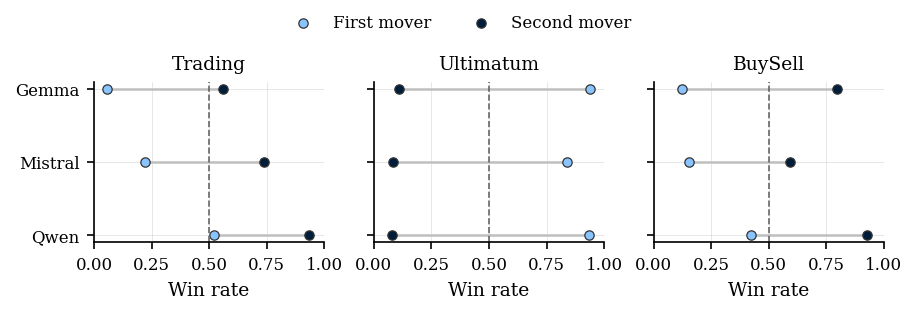

seat                  P1     P2
game      family               
BuySell   Gemma    0.122  0.795
          Mistral  0.152  0.592
          Qwen     0.421  0.926
Trading   Gemma    0.058  0.559
          Mistral  0.222  0.738
          Qwen     0.519  0.935
Ultimatum Gemma    0.938  0.108
          Mistral  0.839  0.082
          Qwen     0.936  0.078

Seat gap (win rate as P2 minus as P1) per family:
seat                  P1     P2  seat_gap
game      family                         
BuySell   Gemma    0.122  0.795     0.673
          Mistral  0.152  0.592     0.440
          Qwen     0.421  0.926     0.505
Trading   Gemma    0.058  0.559     0.501
          Mistral  0.222  0.738     0.515
          Qwen     0.519  0.935     0.415
Ultimatum Gemma    0.938  0.108    -0.830
          Mistral  0.839  0.082    -0.757
          Qwen     0.936  0.078    -0.858

Mean seat gap per game (averaged over families):
game
BuySell      0.539
Trading      0.477
Ultimatum   -0.815


In [22]:
#  Order effect per family: win rate when moving first vs second
fam_seat = (dec.groupby(["game", "family", "seat"])["win"].agg(["mean", "count"])
            .reset_index().rename(columns={"mean": "win_rate", "count": "n"}))
fig, axes = plt.subplots(1, 3, figsize=(FULL_WIDTH, 2.0), sharex=True, sharey=True)
for ax, game in zip(axes, GAMES):
    sub = fam_seat[fam_seat["game"] == game]
    for j, fam in enumerate(FAMILIES):
        fsub = sub[sub["family"] == fam].set_index("seat")
        w1, w2 = fsub.loc["P1", "win_rate"], fsub.loc["P2", "win_rate"]
        ax.plot([w1, w2], [j, j], color="0.75", lw=1.2, zorder=1)
        ax.scatter([w1], [j], s=20, facecolor=BAR2[0], edgecolor="0.2", lw=0.6,
                   zorder=2, label="First mover" if j == 0 else None)
        ax.scatter([w2], [j], s=20, facecolor=BAR2[1], edgecolor="0.2", lw=0.6,
                   zorder=2, label="Second mover" if j == 0 else None)
    ax.axvline(0.5, ls="--", lw=0.8, color="0.4")
    ax.set_yticks(range(len(FAMILIES)), FAMILIES)
    ax.set_xlim(0, 1); ax.set_title(game); ax.set_xlabel("Win rate")
axes[0].invert_yaxis()
fig.legend(*axes[0].get_legend_handles_labels(), loc="outside upper center",
           ncols=2, frameon=False)
save_plot(fig, "role_effect_family_seat")
plt.show()

print(fam_seat.pivot_table(index=["game", "family"], columns="seat", values="win_rate")
      .round(3).to_string())

#  Seat gap (P2 - P1) per family and its per-game mean -- quoted in thesis ch.4 "Role and Turn"
gap = fam_seat.pivot_table(index=["game", "family"], columns="seat", values="win_rate")
gap["seat_gap"] = gap["P2"] - gap["P1"]
print("\nSeat gap (win rate as P2 minus as P1) per family:")
print(gap.round(3).to_string())
print("\nMean seat gap per game (averaged over families):")
print(gap.groupby("game")["seat_gap"].mean().round(3).to_string())


Looking at the plot above we can see that the finding from NegotiationArena also holds in open-weight models:

- Trading and BuySell: the second mover / P2 has an advantage;
- Ultimatum: the proposer / P1 has the advantage.

## 4. Game by game (retry3)

The pooled views in §2 average over three structurally different games.

This section takes them one at a time: who beats whom (full ordered-pair matrices: **rows = the model as Player 1, columns = as Player 2**, so every pair appears twice, once per seat; 


In [23]:
#  Pairwise matrices from MASTER: rows = model as P1, columns = model as P2
def pairwise_panel(game, condition="retry3"):
    g = MASTER[(MASTER["game"] == game) & (MASTER["condition"] == condition)]
    data = {}
    for size in SIZES:
        sub = g[g["size"] == size]
        # one model per family per tier -> order and label by family
        models = sorted(set(sub["model_1"]) | set(sub["model_2"]),
                        key=lambda m: (FAMILIES.index(model_family(m))
                                       if model_family(m) in FAMILIES else 99, m))
        d = sub[sub["winner"].isin(["P1", "P2"])]
        k = (d.assign(w=(d["winner"] == "P1").astype(int))
             .pivot_table(index="model_1", columns="model_2", values="w", aggfunc="sum")
             .reindex(index=models, columns=models))
        n = (d.pivot_table(index="model_1", columns="model_2", values="winner", aggfunc="size")
             .reindex(index=models, columns=models))
        pay = (sub[sub["completed"] & sub["payoff_valid"]]
               .pivot_table(index="model_1", columns="model_2", values="payoff_1")
               .reindex(index=models, columns=models))
        data[size] = (models, k, n, pay)
    pmin = min(p.min().min() for *_, p in data.values())
    pmax = max(p.max().max() for *_, p in data.values())

    fig, axes = plt.subplots(2, 3, figsize=(FULL_WIDTH, 3.8))
    im_win = im_pay = None
    for ci, size in enumerate(SIZES):
        models, k, n, pay = data[size]
        labels = [model_family(m) for m in models]
        im_win = style.heatmap(axes[0, ci], (k / n).values, labels, labels,
                               fmt="{:.2f}", vmin=0, vmax=1)
        im_pay = style.heatmap(axes[1, ci], pay.values, labels, labels,
                               fmt="{:.1f}", vmin=pmin, vmax=pmax)
        axes[0, ci].set_title(SIZE_LABELS[size])
        axes[0, ci].set_xticklabels([])
        axes[1, ci].set_xlabel("as Player 2")
        axes[1, ci].tick_params(axis="x", rotation=30)
        if ci > 0:
            axes[0, ci].set_yticklabels([])
            axes[1, ci].set_yticklabels([])
    axes[0, 0].set_ylabel("Win rate\nas Player 1")
    axes[1, 0].set_ylabel("Mean payoff\nas Player 1")
    cb = fig.colorbar(im_win, ax=axes[0, :], shrink=0.85, pad=0.02)
    cb.set_label("P1 win rate", fontsize=8)
    cb = fig.colorbar(im_pay, ax=axes[1, :], shrink=0.85, pad=0.02)
    cb.set_label("Mean P1 payoff", fontsize=8)
    fig.suptitle(f"{game}  -  row player (P1) win rate and mean payoff vs column player (P2), {condition}")
    save_plot(fig, f"pairwise_{game.lower()}_{condition}")
    plt.show()

    for size, (models, k, n, _) in data.items():
        kn = pd.DataFrame(index=k.index, columns=k.columns, dtype=object)
        for r_ in k.index:
            for c_ in k.columns:
                nn = n.loc[r_, c_]
                kk = 0 if pd.isna(k.loc[r_, c_]) else k.loc[r_, c_]
                kn.loc[r_, c_] = "-" if pd.isna(nn) else f"{int(kk)}/{int(nn)}"
        print(f"{game} {SIZE_LABELS[size]}  -  wins k/n, ties excluded (row = P1):")
        print(kn.to_string(), "\n")

### Trading

Each side starts with 25 units of one resource and 5 of the other and trades freely for up to 8 rounds. With both resources valued at one unit apiece, resources are conserved: every deal is exactly zero-sum (§2.4), so Trading measures pure *claiming*. The paper found the second mover tends to win; §3 confirms it here (the first mover wins only 0.22–0.29 of the games with a winner).


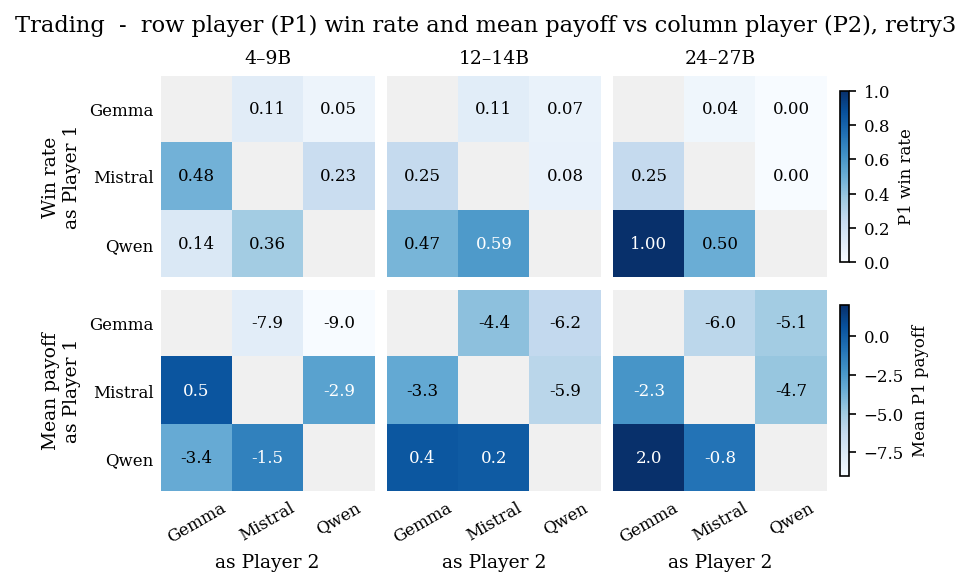

Trading 4–9B  -  wins k/n, ties excluded (row = P1):
model_2             gemma-3-4b-it Ministral-3-8B-2512 Qwen3.5-9B
model_1                                                         
gemma-3-4b-it                   -                2/18       1/21
Ministral-3-8B-2512         14/29                   -       5/22
Qwen3.5-9B                   3/21               10/28          - 

Trading 12–14B  -  wins k/n, ties excluded (row = P1):
model_2              gemma-3-12b-it Ministral-3-14B-2512 Qwen3-14B
model_1                                                           
gemma-3-12b-it                    -                 3/28      2/30
Ministral-3-14B-2512           7/28                    -      2/26
Qwen3-14B                      7/15                10/17         - 

Trading 24–27B  -  wins k/n, ties excluded (row = P1):
model_2                    gemma-3-27b-it Mistral-Small-3.2-24B-2506 Qwen3.5-27B
model_1                                                                         
gemma-3-27b

In [24]:
pairwise_panel("Trading")

- **Qwen Performance increases with scaling while Gemma's degrades.** Qwen climbs 0.543 → 0.784 → 0.892 while
  Gemma slides 0.404 → 0.337 → 0.176;

- **Medium Qwen3.5-27B dominates from both positions**: 26/26 as Player 1 against gemma-3-27b-it and
  a perfect 30/30 + 24/24 as Player 2; the only games it drops are to Mistral-Small when Qwen
  holds the disadvantaged first-mover seat (11/22). No other Trading model dominates from both
  seats.


### Ultimatum

The proposer holds the $100 pot; the responder can accept, counter-propose, or reject and destroy the pot. §3 showed the seat dominates everything else in this game (the proposer wins 0.86–0.97 of the games with a winner), so the interesting variation is *within* the deals: how much do proposers take, and do responders ever push back?


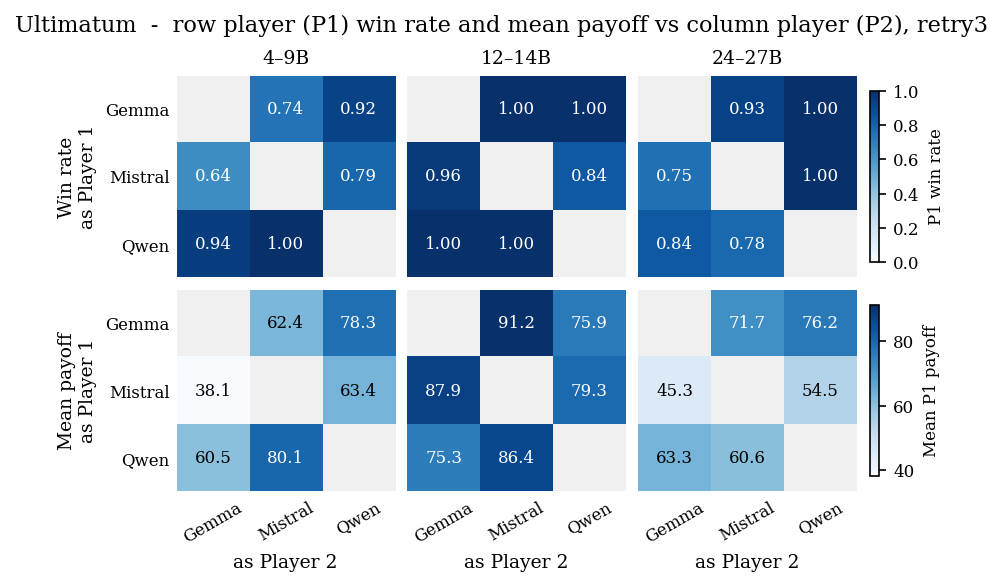

Ultimatum 4–9B  -  wins k/n, ties excluded (row = P1):
model_2             gemma-3-4b-it Ministral-3-8B-2512 Qwen3.5-9B
model_1                                                         
gemma-3-4b-it                   -               17/23      24/26
Ministral-3-8B-2512          9/14                   -      15/19
Qwen3.5-9B                  17/18               23/23          - 

Ultimatum 12–14B  -  wins k/n, ties excluded (row = P1):
model_2              gemma-3-12b-it Ministral-3-14B-2512 Qwen3-14B
model_1                                                           
gemma-3-12b-it                    -                30/30     25/25
Ministral-3-14B-2512          24/25                    -     21/25
Qwen3-14B                     22/22                25/25         - 

Ultimatum 24–27B  -  wins k/n, ties excluded (row = P1):
model_2                    gemma-3-27b-it Mistral-Small-3.2-24B-2506 Qwen3.5-27B
model_1                                                                         
gemma

In [25]:
pairwise_panel("Ultimatum")

#### Do proposers anchor the split?

NegotiationArena found that models differ systematically in how aggressively they open the
Ultimatum: Claude's opening offers to the responder ran on average ~10\$ below GPT's (the paper
notes this left room for a better outcome). A lower offer keeps more of the pot for the proposer. 


We compare the opening offer P1 makes to the responder across families and tiers; the dashed line at 50 marks an
even split, and a lower bar means a more aggressive proposer.

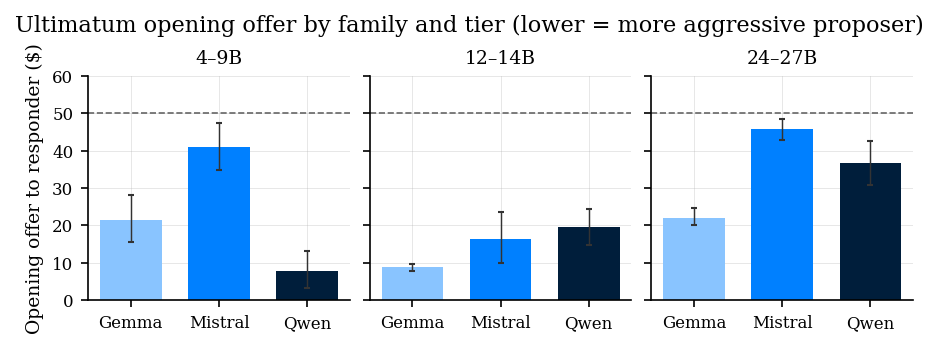

open_offer  p1_payoff   n
tier       family                            
very_small Gemma          21.5       70.5  59
           Mistral        40.9       51.0  59
           Qwen            7.7       70.3  60
small      Gemma           8.8       83.5  60
           Mistral        16.4       83.5  59
           Qwen           19.5       80.5  59
medium     Gemma          22.1       73.9  60
           Mistral        45.8       49.9  60
           Qwen           36.6       62.0  60

open_offer = mean $ offered to the responder on turn 1; p1_payoff = mean $ the proposer keeps (0 when the split is rejected).


In [26]:
#  U1: Ultimatum opening offer (dollars P1 offers the responder), by family x tier
ult = RETRY3[(RETRY3["game"] == "Ultimatum") & RETRY3["outcome_valid"]].copy()
ult = ult[ult["ult_open_offer"].between(0, 100)]

fig, axes = plt.subplots(1, 3, figsize=(FULL_WIDTH, 2.2), sharey=True)
for ax, sz in zip(axes, SIZES):
    sub = ult[ult["size"] == sz]
    for j, fam in enumerate(FAMILIES):
        m, lo, hi = _boot_mean_ci(sub[sub["family_1"] == fam]["ult_open_offer"].values)
        ax.bar(j, m, 0.7, color=fam_pal[fam])
        ax.errorbar(j, m, yerr=[[max(m - lo, 0)], [max(hi - m, 0)]],
                    fmt="none", ecolor="0.2", lw=0.7, capsize=1.5)
    ax.axhline(50, ls="--", lw=0.8, color="0.4")
    ax.set_xticks(range(len(FAMILIES)), FAMILIES)
    ax.set_title(SIZE_LABELS[sz])
axes[0].set_ylabel("Opening offer to responder ($)"); axes[0].set_ylim(0, 60)
fig.suptitle("Ultimatum opening offer by family and tier (lower = more aggressive proposer)")
save_plot(fig, "ultimatum_opening_offer")
plt.show()

#  companion: does opening lower mean keeping more? (payoff_1 = dollars the proposer keeps)
tbl = (ult.groupby(["size", "family_1"])
       .agg(open_offer=("ult_open_offer", "mean"),
            p1_payoff=("payoff_1", "mean"), n=("payoff_1", "size"))
       .round(1).reindex(SIZES, level=0))
tbl.index.names = ["tier", "family"]
display(tbl)
print("open_offer = mean $ offered to the responder on turn 1; "
      "p1_payoff = mean $ the proposer keeps (0 when the split is rejected).")

Mistral is the most generous proposer (opens ≈\$40–46 at the very-small/medium tiers); the more aggressive Gemma and Qwen open far lower and keep more. Very-small Qwen is the
most aggressive proposer of all (opens \$7.7; recovered after the extractor fix below), and Gemma opens lowest at the small and medium tiers (\$8.8 / \$22.1).

#### Do responders reject rationally?

A rejected Ultimatum destroys the entire pot (*both* parties get \$0). 

Rejection only makes sense when punishing a proposer is worth forfeiting the responder's own share. NegotiationArena treats these as evidence of irrationality (its §5)
and notes that risky play yields a bimodal payoff in which "agents do not agree ... and get 0 payoff."


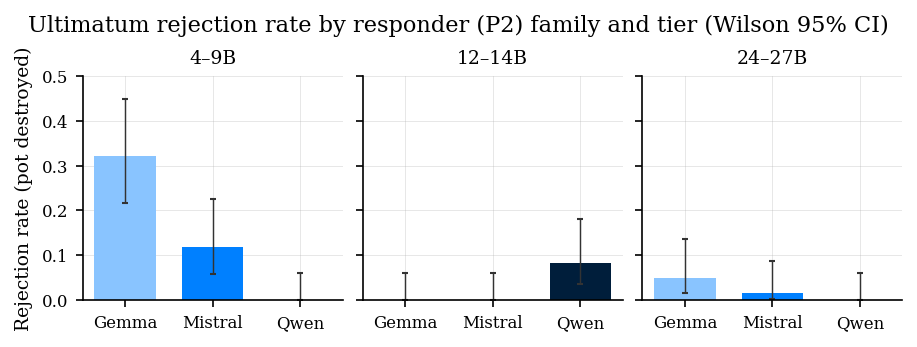

35 of 537 payoff-valid completed games end in rejection -- $3500 of pot destroyed (both parties get $0).


,n_reject,mean_opening_rejected_games,mean_opening_accepted_games
tier,,,
very_small,26,18.9,24.1
small,5,10.0,15.0
medium,4,42.5,34.7


Opening offer ($ to the responder) in games that eventually ended in rejection vs acceptance, among outcome-valid games with a parseable opening. A payoff-maximising agent would usually COUNTER-PROPOSE rather than REJECT, since an outright rejection forfeits the entire pot.

Rejection rate (%) by responder (P2) family and tier:
family_2    Gemma  Mistral  Qwen
size                            
very_small   32.2     11.9   0.0
small         0.0      0.0   8.3
medium        5.0      1.7   0.0


In [27]:
#  U2: Ultimatum rejections destroy the pot -- who rejects, and is it a response to stinginess?
# A rejected Ultimatum gives BOTH parties $0 (the pot is destroyed); the responder is P2.
urej = RETRY3[(RETRY3["game"] == "Ultimatum") & RETRY3["outcome_valid"]].copy()
urej["reject"] = urej["final_response"].astype(str).eq("REJECT")

fig, axes = plt.subplots(1, 3, figsize=(FULL_WIDTH, 2.2), sharey=True)
for ax, sz in zip(axes, SIZES):
    sub = urej[urej["size"] == sz]
    for j, fam in enumerate(FAMILIES):
        g = sub[sub["family_2"] == fam]          # responder = P2
        k, n = int(g["reject"].sum()), len(g)
        rate = k / n if n else np.nan
        lo, hi = wilson_ci(k, n)
        ax.bar(j, rate, 0.7, color=fam_pal[fam])
        ax.errorbar(j, rate, yerr=[[max(rate - lo, 0)], [max(hi - rate, 0)]],
                    fmt="none", ecolor="0.2", lw=0.7, capsize=1.5)
    ax.set_xticks(range(len(FAMILIES)), FAMILIES)
    ax.set_title(SIZE_LABELS[sz])
axes[0].set_ylabel("Rejection rate (pot destroyed)"); axes[0].set_ylim(0, 0.5)
fig.suptitle("Ultimatum rejection rate by responder (P2) family and tier (Wilson 95% CI)")
save_plot(fig, "ultimatum_rejection_rate")
plt.show()

n_rej, n_tot = int(urej["reject"].sum()), len(urej)
print(f"{n_rej} of {n_tot} payoff-valid completed games end in rejection -- "
      f"${n_rej * 100} of pot destroyed (both parties get $0).")

#  the signal: did games that ended in rejection start from stingier offers?
uoff = urej[urej["ult_open_offer"].between(0, 100)]
_rows = []
for sz in SIZES:
    d = uoff[uoff["size"] == sz]
    _rows.append({"tier": sz, "n_reject": int(d["reject"].sum()),
                  "mean_opening_rejected_games": round(d.loc[d["reject"], "ult_open_offer"].mean(), 1),
                  "mean_opening_accepted_games": round(d.loc[~d["reject"], "ult_open_offer"].mean(), 1)})
tbl = pd.DataFrame(_rows).set_index("tier")
display(tbl)
print("Opening offer ($ to the responder) in games that eventually ended in rejection vs acceptance, "
      "among outcome-valid games with a parseable opening. A payoff-maximising agent would usually "
      "COUNTER-PROPOSE rather than REJECT, since an outright rejection forfeits the entire pot.")
#  per-family rejection rate by tier (responder = P2); ch.4 quotes the very-small row
_rej_tbl = (urej.groupby(["size", "family_2"])["reject"].mean()
            .unstack("family_2").reindex(index=SIZES, columns=FAMILIES).mul(100).round(1))
print("\nRejection rate (%) by responder (P2) family and tier:")
print(_rej_tbl.to_string())


35 of 537 payoff-valid completed games end with rejection, overwhelmingly at the very-small tier, where Gemma responders reject **32.2%** of splits (Mistral 11.9%, Qwen 0%). 

### BuySell

The seller (Player 1, private cost 40) and buyer (Player 2, private value 60) negotiate the price of an item. 

Any deal inside [40, 60] profits *both* sides; 

the price decides how the fixed 20-ZUP surplus is split, so a player can earn a positive payoff yet still "lose" on relative win rate — the two metrics measure different things here. 

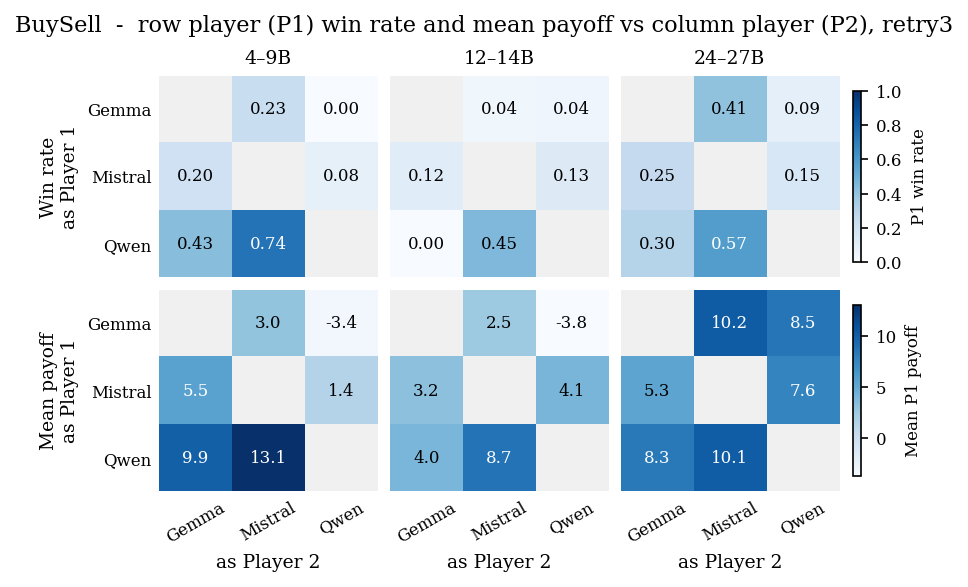

BuySell 4–9B  -  wins k/n, ties excluded (row = P1):
model_2             gemma-3-4b-it Ministral-3-8B-2512 Qwen3.5-9B
model_1                                                         
gemma-3-4b-it                   -                3/13       0/26
Ministral-3-8B-2512          3/15                   -       2/24
Qwen3.5-9B                   6/14               17/23          - 

BuySell 12–14B  -  wins k/n, ties excluded (row = P1):
model_2              gemma-3-12b-it Ministral-3-14B-2512 Qwen3-14B
model_1                                                           
gemma-3-12b-it                    -                 1/26      1/25
Ministral-3-14B-2512           3/26                    -      3/23
Qwen3-14B                      0/20                 9/20         - 

BuySell 24–27B  -  wins k/n, ties excluded (row = P1):
model_2                    gemma-3-27b-it Mistral-Small-3.2-24B-2506 Qwen3.5-27B
model_1                                                                         
gemma-3-27b

In [28]:
pairwise_panel("BuySell")

#### Do sellers anchor the price?

The paper found the opening offer anchors the final price (Spearman ρ = 0.716 for GPT-4). Each point is one deal; the dotted line is opening = final.

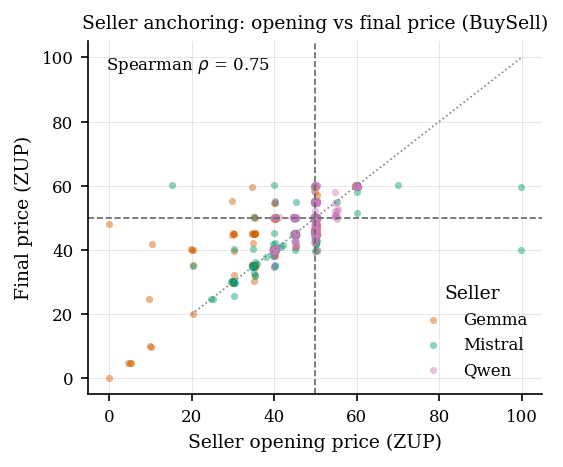

pooled Spearman rho = 0.752 (p = 6.9e-95, n = 515)
  Gemma sellers: rho = 0.718 (n = 165), mean opening 40.2 -> mean final 43.0
  Mistral sellers: rho = 0.784 (n = 170), mean opening 45.0 -> mean final 44.7
  Qwen sellers: rho = 0.681 (n = 180), mean opening 48.5 -> mean final 49.0


In [29]:
#  P5a: anchoring -- seller opening price vs final agreed price
bs = RETRY3[(RETRY3["game"] == "BuySell") & RETRY3["completed"]].copy()
bs["opening"] = bs["prices"].map(lambda p: p[0] if p and p[0] is not None else np.nan)
deals = bs[bs["deal"] & bs["price"].between(0, 100) & bs["opening"].between(0, 200)]

rho, pval = sps.spearmanr(deals["opening"], deals["price"])
fig, ax = plt.subplots(figsize=(FULL_WIDTH * 0.6, 3.0))
rng = np.random.default_rng(0)
for fam in FAMILIES:
    sub = deals[deals["family_1"] == fam]
    ax.scatter(sub["opening"] + rng.uniform(-.4, .4, len(sub)),
               sub["price"] + rng.uniform(-.4, .4, len(sub)),
               s=12, alpha=0.45, color=dot_pal[fam], label=fam, lw=0)
lims = [20, 100]
ax.plot(lims, lims, color="0.5", lw=0.8, ls=":")
ax.axhline(50, ls="--", lw=0.8, color="0.4"); ax.axvline(50, ls="--", lw=0.8, color="0.4")
ax.text(0.04, 0.96, f"Spearman $\\rho$ = {rho:.2f}", transform=ax.transAxes,
        va="top", fontsize=8)
ax.set_xlabel("Seller opening price (ZUP)"); ax.set_ylabel("Final price (ZUP)")
ax.legend(title="Seller", loc="lower right", frameon=False)
ax.set_title("Seller anchoring: opening vs final price (BuySell)")
save_plot(fig, "buysell_seller_anchoring")
plt.show()

print(f"pooled Spearman rho = {rho:.3f} (p = {pval:.1e}, n = {len(deals)})")
for fam in FAMILIES:
    sub = deals[deals["family_1"] == fam]
    r, p = sps.spearmanr(sub["opening"], sub["price"])
    print(f"  {fam} sellers: rho = {r:.3f} (n = {len(sub)}), "
          f"mean opening {sub.opening.mean():.1f} -> mean final {sub.price.mean():.1f}")

**Anchoring replicates at GPT-4 magnitude.** The final price correlates strongly with the seller's opening offer (Spearman ρ = 0.75, n ≈ 515 deals; the paper reports ρ = 0.716 for GPT-4). This means: **sellers who open higher tend to close higher**. 

  - Gemma sellers cluster lower, often opening near or below 40. That means they
    sometimes concede seller surplus immediately, and may even open below cost.

  - Qwen sellers cluster higher, often around 45-55, and therefore tend to
    finish at higher prices.

  - Mistral sellers sit between them but also show a strong opening-to-final
    relationship.


#### Do they make irrational moves?

Two moves are irrational by construction: a seller offering below its own cost of 40, and a buyer offering above its value of 60. 

In [30]:
#  P5c: irrational moves 
def seller_offers(p): return [x for x in (p or [])[0::2] if x is not None]
def buyer_offers(p):  return [x for x in (p or [])[1::2] if x is not None]

bs["seller_open_below_cost"] = bs["prices"].map(
    lambda p: p[0] is not None and p[0] < 40 if p else np.nan)
bs["seller_any_below_cost"] = bs["prices"].map(
    lambda p: any(x < 40 for x in seller_offers(p)) if seller_offers(p) else np.nan)
bs["buyer_any_above_value"] = bs["prices"].map(
    lambda p: any(x > 60 for x in buyer_offers(p)) if buyer_offers(p) else np.nan)
bs["deal_seller_loss"] = np.where(bs["deal"], bs["price"] < 40, np.nan)
bs["deal_buyer_loss"] = np.where(bs["deal"], bs["price"] > 60, np.nan)

seller_side = (bs.groupby(["size", "family_1"])
               [["seller_open_below_cost", "seller_any_below_cost", "deal_seller_loss"]]
               .mean())
buyer_side = (bs.groupby(["size", "family_2"])
              [["buyer_any_above_value", "deal_buyer_loss"]].mean())
irr = seller_side.join(buyer_side.rename_axis(seller_side.index.names)).round(3)
irr.index.names = ["size", "family"]
irr = irr.reindex(SIZES, level=0)
display(irr)

print("Rates are per game in that role (seller cols: family as P1; buyer cols: family as P2).")
print(f"\nOverall: sellers open below their own cost in {bs.seller_open_below_cost.mean():.1%} "
      f"of games; {bs.deal_seller_loss.mean():.1%} of deals close below cost "
      f"(seller loss), {bs.deal_buyer_loss.mean():.1%} above 60 (buyer loss).")

seller_open_below_cost seller_any_below_cost  \
size       family                                                  
very_small Gemma                     0.212               0.22449   
           Mistral                   0.220              0.237288   
           Qwen                      0.000                   0.0   
small      Gemma                     0.767              0.783333   
           Mistral                   0.267              0.288136   
           Qwen                      0.000              0.033333   
medium     Gemma                     0.000                   0.0   
           Mistral                   0.000              0.083333   
           Qwen                      0.000                   0.0   

                    deal_seller_loss buyer_any_above_value  deal_buyer_loss  
size       family                                                            
very_small Gemma               0.188              0.111111              0.0  
           Mistral             0.189                   0.0              0.0  
           Qwen                0.000                   0.0              0.0  
small      Gemma               0.467                   0.0              0.0  
           Mistral             0.217                   0.0              0.0  
           Qwen                0.033                   0.0              0.0  
medium     Gemma               0.000                   0.0              0.0  
           Mistral             0.086                   0.0              0.0  
           Qwen                0.000                   0.0              0.0

Rates are per game in that role (seller cols: family as P1; buyer cols: family as P2).

Overall: sellers open below their own cost in 16.2% of games; 12.9% of deals close below cost (seller loss), 0.0% above 60 (buyer loss).



  
- **Irrationality is concentrated on the seller side:** 

  - Gemma-3-12B-IT is the clearest case.
      - It opens below its own production cost in 77% of seller games.
      - In 47% of its completed deals, the final price is below cost, so the seller makes a loss.

  - Qwen sellers are much more rational.
      - They almost never open below cost or accept loss-making deals.
      - Both behaviours occur only around 0-3% of the time.

  - Buyers do not show the same realised irrationality.
      - Under the current extractor, buyer-side above-value proposals are not observed in these retry3 logs.
      - No completed deal closes above 60, so buyers never actually accept a loss-making final price.

  - Overall pattern:
      - Loss-making outcomes are almost entirely a seller-side problem.
      - This matches the original NegotiationArena finding that LLMs tend to perform better as buyers than as sellers.


#### Buyer vs seller: who captures the surplus?

NegotiationArena reported the final price sits **below** the 50 midpoint and that LLMs do better as
**buyers** than as sellers. In our setup P1 is the seller (cost 40) and P2 the buyer (value 60), so
a deal at price $p$ gives the seller $p-40$ and the buyer $60-p$.

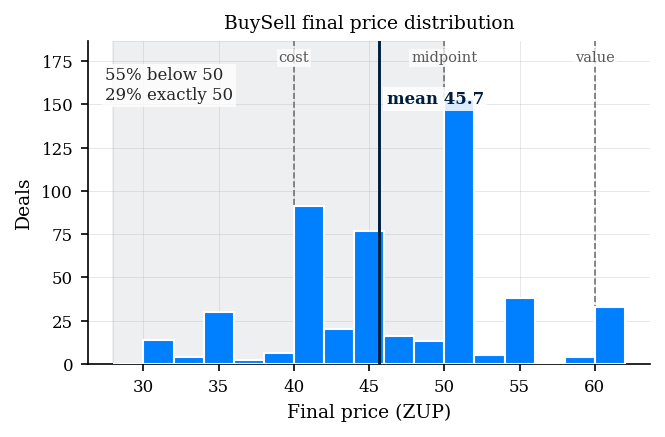

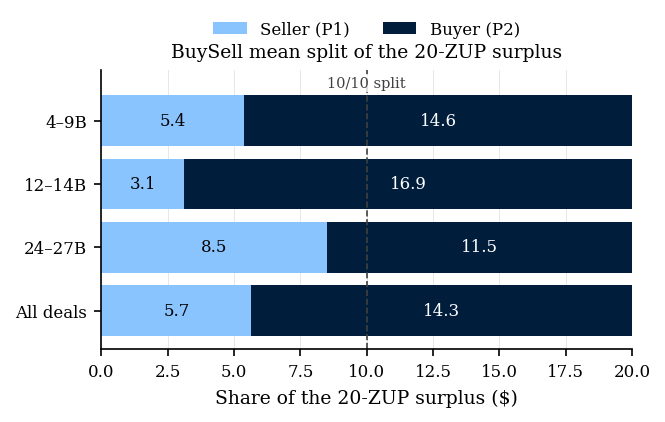

Deals below midpoint: 54.8%; exactly 50: 28.8%; mean price 45.7
Mean surplus -- seller 5.7  buyer 14.3 (of 20 total)


In [31]:
#  B1a: where BuySell deals land on the seller(40)->buyer(60) bargaining zone
bsd = bs[bs["deal"] & bs["price"].between(0, 100)].copy()
seller_c = BAR2[0]
buyer_c = BAR2[1]

mp = bsd["price"].mean()
pct_below = (bsd["price"] < 50).mean()
pct_mid = (bsd["price"] == 50).mean()

fig, ax = plt.subplots(figsize=(FULL_WIDTH * 0.72, 2.8))
counts, _, _ = ax.hist(bsd["price"], bins=np.arange(28, 63, 2),
                       color=DEFAULT_PALETTE[2], edgecolor="white", zorder=3)
top = counts.max() * 1.22
ax.set_ylim(0, top)
ax.axvspan(28, 50, color=buyer_c, alpha=0.07, zorder=0)
for xv, lab in [(40, "cost"), (50, "midpoint"), (60, "value")]:
    ax.axvline(xv, ls="--", color="0.45", lw=0.8, zorder=2)
    ax.text(xv, 0.97, lab, transform=ax.get_xaxis_transform(),
            ha="center", va="top", fontsize=7, color="0.35",
            bbox=dict(facecolor="white", edgecolor="none", alpha=0.75, pad=1.0))
ax.axvline(mp, color=RED, lw=1.4, zorder=4)
ax.text(mp + 0.5, 0.82, f"mean {mp:.1f}", transform=ax.get_xaxis_transform(),
        ha="left", va="center", fontsize=8, color=RED, fontweight="bold",
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.85, pad=1.5))
ax.text(0.03, 0.92, f"{pct_below:.0%} below 50\n{pct_mid:.0%} exactly 50",
        transform=ax.transAxes, ha="left", va="top", fontsize=8, color="0.15",
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.8, pad=1.5))
ax.set_xlabel("Final price (ZUP)")
ax.set_ylabel("Deals")
ax.set_title("BuySell final price distribution")
save_plot(fig, "buysell_final_price_distribution")
plt.show()

#  B1b: mean split of the 20-ZUP surplus, seller vs buyer (sums to 20 by construction)
groups = [(SIZE_LABELS[s], s) for s in SIZES] + [("All deals", None)]
y = np.arange(len(groups))[::-1]
sell = [(bsd if k is None else bsd[bsd["size"] == k])["payoff_1"].mean() for _, k in groups]
buy = [(bsd if k is None else bsd[bsd["size"] == k])["payoff_2"].mean() for _, k in groups]

fig, ax = plt.subplots(figsize=(FULL_WIDTH * 0.72, 2.7))
ax.barh(y, sell, color=seller_c, label="Seller (P1)")
ax.barh(y, buy, left=sell, color=buyer_c, label="Buyer (P2)")
for yi, s, b in zip(y, sell, buy):
    ax.text(s / 2, yi, f"{s:.1f}", ha="center", va="center", color="black", fontsize=8)
    ax.text(s + b / 2, yi, f"{b:.1f}", ha="center", va="center", color="white", fontsize=8)
ax.axvline(10, ls="--", color="0.25", lw=0.8)
ax.text(10, max(y) + 0.48, "10/10 split", ha="center", va="bottom",
        fontsize=7, color="0.25",
        bbox=dict(facecolor="white", edgecolor="none", alpha=0.8, pad=1.0))
ax.set_ylim(-0.6, max(y) + 0.8)
ax.set_yticks(y, [g for g, _ in groups])
ax.set_xlim(0, 20)
ax.set_xlabel("Share of the 20-ZUP surplus ($)")
ax.set_title("BuySell mean split of the 20-ZUP surplus")
ax.legend(loc="lower center", bbox_to_anchor=(0.5, 1.06), ncols=2, frameon=False)
save_plot(fig, "buysell_surplus_split")
plt.show()

print(f"Deals below midpoint: {pct_below:.1%}; exactly 50: {pct_mid:.1%}; "
      f"mean price {mp:.1f}")
print(f"Mean surplus -- seller {bsd['payoff_1'].mean():.1f}  buyer {bsd['payoff_2'].mean():.1f} "
      f"(of 20 total)")



- **The buyer captures the larger share** 
  - 55% of deals close below the 50 midpoint and 29% land exactly on 50; the midpoint is a strong focal point. 
  - The buyer captures the larger share mean surplus 14.3\$ for the buyer vs 5.7\$ for the seller 

### Replication scorecard vs NegotiationArena

A claim-by-claim summary: which of NegotiationArena's frontier-model findings reappear in
open-weight cross-play. ✓ = same direction and similar magnitude; *analog* = same qualitative pattern but
not directly comparable (different models or setup).

In [32]:
#  Scorecard: NegotiationArena claim vs open-weight result (numbers recomputed inline)
def _p1_winrate(game):
    d = RETRY3[(RETRY3["game"] == game) & RETRY3["winner"].isin(["P1", "P2"])]
    return (d["winner"] == "P1").mean()

# BuySell anchoring rho (opening -> final)
_an = RETRY3[(RETRY3["game"] == "BuySell") & RETRY3["deal"]].copy()
_an["opening"] = _an["prices"].map(lambda p: p[0] if p and p[0] is not None else np.nan)
_an = _an[_an["price"].between(0, 100) & _an["opening"].between(0, 200)]
rho_bs, _ = sps.spearmanr(_an["opening"], _an["price"])

# BuySell price vs midpoint + buyer/seller surplus
_bd = RETRY3[(RETRY3["game"] == "BuySell") & RETRY3["deal"] & RETRY3["price"].between(0, 100)]
below = (_bd["price"] < 50).mean()
seller_m, buyer_m = _bd["payoff_1"].mean(), _bd["payoff_2"].mean()

# Ultimatum opening offer by tier
_u = RETRY3[(RETRY3["game"] == "Ultimatum") & RETRY3["outcome_valid"]]
_u = _u[_u["ult_open_offer"].between(0, 100)]
open_by_tier = _u.groupby("size")["ult_open_offer"].mean().reindex(SIZES)

scorecard = pd.DataFrame([
    ["Ultimatum: proposer (P1) almost always wins", "P1 dominates",
     f"P1 win {_p1_winrate('Ultimatum'):.0%}", "✓"],
    ["Trading: second-mover advantage", "P1 often loses",
     f"P1 win {_p1_winrate('Trading'):.0%}", "✓"],
    ["BuySell: second-mover advantage", "P1 often loses",
     f"P1 win {_p1_winrate('BuySell'):.0%}", "✓"],
    ["BuySell anchoring (opening → final, Spearman ρ)", "ρ = 0.716 (GPT-4)",
     f"ρ = {rho_bs:.2f}", "✓"],
    ["BuySell final price below the 50 midpoint", "< 50 typical",
     f"{below:.0%} below 50", "✓"],
    ["LLMs do better as buyer than seller", "buyer advantage",
     f"buyer {buyer_m:.1f}$ vs seller {seller_m:.1f}$", "✓" if buyer_m > seller_m else "✗"],
], columns=["NegotiationArena claim", "Their result", "Open-weight result", "Matches?"])
display(scorecard.style.hide(axis="index"))

NegotiationArena claim,Their result,Open-weight result,Matches?
Ultimatum: proposer (P1) almost always wins,P1 dominates,P1 win 91%,✓
Trading: second-mover advantage,P1 often loses,P1 win 25%,✓
BuySell: second-mover advantage,P1 often loses,P1 win 23%,✓
"BuySell anchoring (opening → final, Spearman ρ)",ρ = 0.716 (GPT-4),ρ = 0.75,✓
BuySell final price below the 50 midpoint,< 50 typical,55% below 50,✓
LLMs do better as buyer than seller,buyer advantage,buyer 14.3$ vs seller 5.7$,✓


<!-- CONCLUSIONS -->
## 5. Conclusions

1. **Self-Correction Works.** Completion without self-correction is an inverted-U in
   size (medium Trading 0.678) and a 3-retry budget restores ≥ 0.99 almost everywhere for ≈0.3
   extra generations per game (0.36 if each budget-exhausting failure is charged the full 3 retries). 
2. **Family rankings remain across scales.** The pooled ranking Qwen
   (0.63–0.67) > Gemma (≈0.45) > Mistral (0.38–0.43) is identical in all three tiers; 4B → 27B
   scaling never reorders it. In the Trading and BuySell games Qwen is the winner, while in the
   Ultimatum game Gemma is the winner.
3. **Role asymmetry remains.** Proposer dominance in Ultimatum
   (0.86–0.97) and second-mover advantage in Trading and BuySell (P1 wins 0.215–0.286 in Trading and 0.121–0.325 in BuySell) exists in open-weight models, matching NegotiationArena's directional finding.
4. **Ultimatum proposers anchor, and aggression varies by family and tier.** Open-weight proposers offer the responder
   far below an even split (mean ≈24\$ of 100), and the opening offer separates families and tiers.
5. **Buyer advantage and sub-midpoint prices match the original pattern.** BuySell deals close below the 50 midpoint
   and the buyer (P2) captures more surplus than the seller (P1), matching NegotiationArena's
   frontier-model result. 
6. **Outright rejection is value destruction concentrated in weak models.** 35 payoff-valid Ultimatum games end
   in a REJECT that zeroes out both players (\$3,500 of pot) — overwhelmingly weak (very-small)
   responders, Gemma worst at a 32.2% reject rate — who forfeit the pot rather than counter-propose,
   even though games ending in rejection began with modestly lower openings than accepted games. This is the
   value-destruction NegotiationArena flags as irrationality.
